# Trader Execution

Walk-forward is the test design: train on the past, test on the next unseen stretch, with a hard fenced split so nothing leaks across. This chapter runs the machine-learning workflow on Binance 1-hour spot data, drawn survivorship-complete from the `data.binance.vision` archive: the full historical USDT universe (612 pairs, roughly a third of them delisted), point-in-time screened per bar rather than the survivor-only active list.

The work runs in stages: build and label the 1h dataset, screen the candidate features (elastic-net / glmnet path), fit logistic regression, random forest and LightGBM head-to-head under a 60/40 confidence filter, assess and tune on blind data to nominate a best model, then test stability against buy-and-hold, a coin flip, and a triple-Supertrend rules baseline before any capital is risked.

All metrics are compiled in `outputs/AA-evals/`, comparing the features and ATR-scaled label from `inputs/build_dataset_1h.py`, the final-year split from `inputs/train_model_1h.py`, the per-model scoring from `inputs/train_model.py`, and the four-metric evaluation from `inputs/eval_report.py`. Run it from the project `.venv`, which holds `pandas-ta` and `TA-Lib`.

### Supertrend Integration

The triple-Supertrend work added this cycle lives in three places in this chapter:
- **Features** (`### Feature Variables`): `inputs/build_dataset_1h.py` `supertrend_block()` emits the `f_st_` family - three ATR-channel bands voting, signed band distances, the reversal flip, EMA-200 distance - ported from the live bot `inputs/supertrend.py`. Activates on the next dataset rebuild.
- **Baseline** (`### Stability`): `inputs/baseline_supertrend_1h.py` trades the bot's long-only rule on the out-of-sample year and scores it after fees through ClaudeTrader's metrics - the rules benchmark the model must beat.
- **Engine**: ClaudeTrader installed editable into the `.venv` supplies the risk and performance modules behind the baseline.

Chapter One frames the Supertrend as a trend vote; Chapter Two as an ATR exit/sizing control. Full record: `tasks/integration-2026-06-23-claudetrader-supertrend.md`.

### Environment

This notebook must run on the project .venv kernel "Python (day-trader .venv)", which holds joblib, scikit-learn, lightgbm, ccxt, pandas-ta and TA-Lib. In Jupyter you do NOT "activate" a venv in a shell, you select its kernel: Kernel menu >> Change Kernel >> "Python (day-trader .venv)". If that kernel is not listed, register it once from a terminal, then reopen the notebook:

```
   /Volumes/PortableSSD/Github/day-trader/.venv/bin/python -m ipykernel install --user \
       --name day-trader --display-name "Python (day-trader .venv)"
```

In [1]:
import os, sys
from pathlib import Path


if sys.version_info[:2] < (3, 11):
    raise RuntimeError(f"Use the project .venv (Python 3.12); kernel is {sys.version.split()[0]}.")
try:
    import numpy as np, pandas as pd, joblib
    import matplotlib.pyplot as plt
except ModuleNotFoundError as e:
    raise RuntimeError(
        f"Missing '{e.name}'. This kernel is not the project .venv (running {sys.executable}). "
        "Switch to 'Python (day-trader .venv)' via Kernel -> Change Kernel, then re-run."
    ) from e

# Shared modeling + evaluation code: the SAME functions the scripts run.
INPUTS_DIR = None
for cand in ["inputs", os.path.join("..", "inputs")]:
    if os.path.isdir(cand):
        INPUTS_DIR = os.path.abspath(cand)
        sys.path.insert(0, INPUTS_DIR); break
REPO_ROOT = Path(INPUTS_DIR).parent          # repo root = parent of inputs/, regardless of cwd
import build_dataset_1h as bd        # 1h features, ATR-scaled label, point-in-time screen
import train_model as tm             # shared: build_models, evaluate, confidence_filtered, costs
import train_model_1h as t1          # 1h load + final-year split
import eval_report
HAVE_LGBM = tm.HAVE_LGBM

def _layer(mod):
    try:
        __import__(mod); return "yes"
    except Exception:
        return "no"

OUTPUTS = REPO_ROOT / "outputs"                          # absolute <repo>/outputs, never the cwd-relative one
MODEL_DIR = OUTPUTS / "3B-model-training"; MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"outputs -> {OUTPUTS}")
print(f"env ready  .  kernel: {sys.executable}")
print(f"python {sys.version.split()[0]}  .  lightgbm {'yes' if HAVE_LGBM else 'no'}"
      f"  .  pandas-ta {_layer('pandas_ta')}  .  TA-Lib {_layer('talib')}")

# --- inline table rendering (Positron-safe) -------------------------------------------
# Positron routes a bare display(df) to its live Data Explorer pane, which shows blank
# inline and dies on reload. show_table() emits a static HTML table that renders in the
# cell and survives reload, in Positron, Jupyter and VS Code alike.
from IPython.display import HTML, display, Markdown, Image  # noqa: F401  (Markdown/Image used later)

def show_table(x):
    obj = x.to_frame() if (hasattr(x, "to_frame") and getattr(x, "ndim", 2) == 1) else x
    display(HTML(obj.to_html()))


# --- inline figure rendering (Positron-safe) ------------------------------------------
# Positron (and nbconvert with a non-interactive backend) route plt.show() to a side pane, so
# matplotlib figures never embed in the .ipynb and the saved notebook reads blank. show_fig()
# rasterises the figure to an inline PNG that renders in the cell and survives reload -- the
# plot analogue of show_table() above. Pass a Figure; None is tolerated (some plotters return
# None when there is nothing to draw). Use show_fig(fig) in place of plt.show().
import io as _io

def show_fig(fig, dpi=120):
    if fig is None:
        print("(no figure to show)"); return
    buf = _io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))


outputs -> /Volumes/PortableSSD/Github/day-trader/outputs
env ready  .  kernel: /Volumes/PortableSSD/Github/day-trader/.venv/bin/python
python 3.12.13  .  lightgbm yes  .  pandas-ta yes  .  TA-Lib yes


### Data Preparation

Everything between the raw exchange archives and the first model lives here. The operations are defined once in `inputs/build_dataset_1h.py` and `inputs/train_model_1h.py`; the cells here load the prepared data and list the predictor families. Acquisition (dead coins included), profiling and the split are owned by the Survivorship Pipeline section below and documented in `tasks/data-pipeline-methodology.md`.

One row per coin per hour across the full USDT spot market, each row kept only if that coin was tradable at that hour (the point-in-time screen). Predictors are scale-invariant (ratios and distances, so one model fits a \$60k coin and a \$0.20 coin). The label is an ATR-scaled triple barrier on a short day-trade horizon: a win is a +2 ATR rise before a -1 ATR drop, within 48 hours.

The cleaning, the point-in-time screen, the survivorship correction and the forward-chained split are the subject of the Survivorship Pipeline below, each with its own diagnostic. Stage A enumerates the historical universe from the archive so delisted coins are present; Stage B profiles coverage, gaps, breadth and liquidity and derives the usable start, minimum history and purge/embargo; Stage C splits forward in time with that embargo and point-in-time per-fold universes.

### Training-Test Split

We split by time on purpose, so we cannot force class proportions; instead we audit whether the temporal, multi-coin split is representative, on three fronts.

1. Panel composition. The pool mixes hundreds of coins with unequal history (BTC to 2017, newer coins about two years), so the model is implicitly weighted toward long-history coins and the regimes they lived through. Check the row share per coin in train and test, the per-coin base rate on each side, and which coins appear in only one window.

2. Temporal drift. Because the split is by time, the hold-out can be a different regime, so a NO-GO with large drift means regime change, not absence of edge. Compare the label rate and each feature's distribution between the training years and the test year: base-rate shift (two-proportion z-test), continuous drift (Kolmogorov-Smirnov plus a ranked Population Stability Index, flag PSI above 0.10 and 0.25), and proportion shift on the binary features. Re-assert that the embargo separates the last training label from the first test bar.

3. Label imbalance. The barrier label is roughly 0.32 positive. We act on calibrated probabilities above a 0.60 threshold rather than argmax, and `class_weight="balanced"` distorts exactly those probabilities, so class-weighting and SMOTE (fit strictly within the training fold) are candidates graded on the after-fee metric and on calibration, not defaults. Any resampling stays inside the training window; cross-validation is embargoed and time-indexed, never shuffled.

Cohen's Kappa, per-class precision, recall and F1, the confusion matrix and OOB are diagnostics for whether the minority class is learned; they do not decide the outcome. The after-fee Metric 2 (net expectancy per confident trade, against buy-and-hold and a coin-flip) remains the deciding number.

### Next Steps

The cell below surfaces the active knobs (split size, trade filter, costs, label), read-only from the scripts. Then Import Data loads the prepared dataset and Feature Variables lists the candidate families. Acquisition, profiling and splitting are exercised in the Survivorship Pipeline section; modelling follows from Variable Selection.

### Multi-Resolution Datasets

The model is trained per decision frame, not on one fixed resolution. Three frames are built from the
same survivorship-complete history, each as its own dataset:

- 1h (existing): the original day-trade frame, `dataset_1h_allmarket.parquet`.
- 4h (new, 2026-06-23): `dataset_4h_allmarket.parquet`, added because 1h direction prediction sits at
  the efficient-market floor (label sweeps, the model zoo, and Monte Carlo all land NO-GO at 1h).
  Coarser frames are where trend survives fees, so 4h is the first place to look for demonstrable,
  after-fee, survivorship-correct edge.
- daily (planned): the trend / context frame, next in the build plan.

One builder serves every frame. `build_dataset_1h.configure(interval_hours)` retunes the
interval-sensitive knobs in place: the wall-clock feature windows scale by bars-per-day, the label
horizon stays a fixed 2 wall-clock days, the liquidity/ATR/spread screen and its band rescale, and the
higher-timeframe context shifts (1h sees 4h and daily; 4h sees daily and weekly; daily sees weekly and
monthly). The conventional oscillator periods are held constant. `configure(1)` reproduces the shipped
1h frame exactly, so nothing drifts. Build any frame with `build_dataset_1h.py --interval {1,4,24}`.

Characteristics shared by every frame: causal, scale-invariant features (~90), an ATR-scaled
triple-barrier label, a point-in-time liquidity screen that leaves a liquid trainable core of roughly
fifty coins, the final year held out of sample, and after-fee scoring. Frames are never pooled at the
row level; they combine only at the signal level. The cell below shows the download provenance, proves
the source with a live fetch, reports the on-disk footprint, and compares the built frames head to head.

In [2]:
# Data provenance + the multi-resolution footprint, in one place. Source for EVERY frame is the official
# Binance archive at data.binance.vision (exchange-direct monthly OHLCV zips, checksummed, offline-
# reproducible); ccxt is only a live top-up for the forming bar. This cell (1) shows the download + build
# command per frame, (2) proves the source with a one-month live fetch at 1h and 4h, (3) reports what is
# on disk, and (4) compares the built 1h vs 4h datasets head to head (computed live so it never goes stale).
import io, zipfile, urllib.request
BINANCE_VISION = "https://data.binance.vision/"
def vision_url(symbol, interval, month):
    return f"{BINANCE_VISION}data/spot/monthly/klines/{symbol}/{interval}/{symbol}-{interval}-{month}.zip"

prov = pd.DataFrame([
    ("1h  (old)", "acquire_vision.py download --interval 1h ; flow_data.py --interval 1h ; build_dataset_1h.py", "klines_1h/", "dataset_1h_allmarket.parquet"),
    ("1d  (old)", "flow_data.py --interval 1d --all-market", "klines/", "daily_flow.csv"),
    ("4h  (new)", "acquire_vision.py download --interval 4h ; flow_data.py --interval 4h --skip-download ; build_dataset_1h.py --interval 4", "klines_4h/", "dataset_4h_allmarket.parquet"),
], columns=["frame", "download + build command", "raw klines", "built dataset"])
print("PROVENANCE  (one source: data.binance.vision; survivorship-complete via acquire_vision.py crawl)\n")
show_table(prov)

print("LIVE proof of source + format (one month each, straight from the archive):")
for interval in ("1h", "4h"):
    u = vision_url("BTCUSDT", interval, "2024-01")
    try:
        raw = urllib.request.urlopen(u, timeout=15).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        n = len(pd.read_csv(io.BytesIO(z.read(z.namelist()[0])), header=None))
        print(f"  {interval}: {n:3d} bars, {len(raw)/1024:4.0f} KB  <-  {u}")
    except Exception as e:
        print(f"  {interval}: offline ({e})")

# on-disk footprint (raw archives are git-ignored + regenerable; the built datasets are the deliverable)
bd_dir = REPO_ROOT / "inputs" / "binance-data"
def _coins(sub):
    p = bd_dir / sub
    return sum(1 for d in os.listdir(p) if (p / d).is_dir() and not d.startswith("._")) if p.exists() else 0
def _mb(f):
    p = bd_dir / f
    return f"{p.stat().st_size/1e6:.0f} MB" if p.exists() else "not built"
print("\nON DISK:")
for sub, ds in [("klines_1h", "dataset_1h_allmarket.parquet"), ("klines_4h", "dataset_4h_allmarket.parquet")]:
    print(f"  {sub:10s} {_coins(sub):3d} coin folders   ->   {ds}: {_mb(ds)}")

# head-to-head characteristics of the BUILT datasets
print("\nDATASET CHARACTERISTICS (built frames):")
rows = []
for iv, path in [(1, bd_dir / "dataset_1h_allmarket.parquet"), (4, bd_dir / "dataset_4h_allmarket.parquet")]:
    if not path.exists():
        continue
    d = bd.read_frame(str(path)); fc = bd.feature_columns(d); ins = d[d["in_sample"]]
    rows.append({"frame": bd._INTERVAL_LABEL[iv], "rows": f"{len(d):,}", "coins": d["symbol"].nunique(),
                 "features": len(fc), "in-sample rows": f"{len(ins):,}",
                 "base rate (in)": round(ins["label"].mean(), 3),
                 "MTF context": ",".join(pre for _, pre in bd._MTF_RULES[iv]),
                 "span": f"{d['datetime'].min():%Y-%m} -> {d['datetime'].max():%Y-%m}"})
if rows:
    show_table(pd.DataFrame(rows).set_index("frame"))
print("Each frame is its own dataset (never pool rows across resolutions); combine only at the signal "
      "level.\nThe 4h frame exists because 1h direction sits at the efficient-market floor; coarser frames "
      "are\nwhere after-fee, survivorship-correct edge may survive (see tasks/multi-resolution-build-plan.md).")


PROVENANCE  (one source: data.binance.vision; survivorship-complete via acquire_vision.py crawl)



,frame,download + build command,raw klines,built dataset
0,1h (old),acquire_vision.py download --interval 1h ; flow_data.py --interval 1h ; build_dataset_1h.py,klines_1h/,dataset_1h_allmarket.parquet
1,1d (old),flow_data.py --interval 1d --all-market,klines/,daily_flow.csv
2,4h (new),acquire_vision.py download --interval 4h ; flow_data.py --interval 4h --skip-download ; build_dataset_1h.py --interval 4,klines_4h/,dataset_4h_allmarket.parquet


LIVE proof of source + format (one month each, straight from the archive):
  1h: 744 bars,   42 KB  <-  https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-2024-01.zip
  4h: 186 bars,   11 KB  <-  https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/4h/BTCUSDT-4h-2024-01.zip

ON DISK:
  klines_1h  600 coin folders   ->   dataset_1h_allmarket.parquet: 684 MB
  klines_4h  600 coin folders   ->   dataset_4h_allmarket.parquet: 2008 MB

DATASET CHARACTERISTICS (built frames):


,rows,coins,features,in-sample rows,base rate (in),MTF context,span
frame,,,,,,,
1h,"1,640,660",47,61,"458,539",0.313,"f_4h,f_d1",2017-10 -> 2026-06
4h,"3,939,629",567,90,"125,416",0.262,"f_d1,f_w1",2017-11 -> 2026-06


Each frame is its own dataset (never pool rows across resolutions); combine only at the signal level.
The 4h frame exists because 1h direction sits at the efficient-market floor; coarser frames are
where after-fee, survivorship-correct edge may survive (see tasks/multi-resolution-build-plan.md).


In [3]:
# Knobs live in the scripts so the notebook cannot drift. Read-only here.
CONFIG = dict(
    oos_days     = t1.OOS_DAYS,         # final year held out of sample
    embargo_days = t1.EMBARGO_DAYS,     # = label horizon in days
    conf_hi      = tm.CONF_HI,          # confidence filter act-long (Keller Metric 1)
    conf_lo      = tm.CONF_LO,          # act-short / stand-aside
    cost_pct     = tm.COST_PCT,         # round-trip drag (fee + slippage), Metric 2
)
lab = bd.LABEL
print(f"label: +{lab['tgt_atr']} ATR before -{lab['stp_atr']} ATR within {lab['horizon_bars']} bars "
      f"({lab['horizon_bars']//bd.BARS_PER_DAY}d)  .  hold out final {CONFIG['oos_days']}d, "
      f"embargo +/-{CONFIG['embargo_days']}d  .  confidence {CONFIG['conf_lo']}-{CONFIG['conf_hi']}  .  "
      f"cost {CONFIG['cost_pct']:.2f}% round trip")

label: +2.0 ATR before -1.0 ATR within 48 bars (2d)  .  hold out final 365d, embargo +/-2d  .  confidence 0.4-0.6  .  cost 0.20% round trip


### Import Data

Loads the prepared 1h dataset at `inputs/binance-data/dataset_1h_allmarket.parquet` (via `bd.DATASET_PATH`), built offline from the `data.binance.vision` archives by `inputs/build_dataset_1h.py`; `t1.load` reads it and keeps only the point-in-time `in_sample` rows. If it has not been built, the cell prints the build command. The cleaning, screen and label that produced this file are described once in Data Preparation above, so they are not repeated here.

The build is incremental and runs on demand via `tasks/run_auto_eval.sh`; it can also run nightly from cron, pulling the latest 24 hours, rebuilding the dataset, and retraining, so the load always reflects the most recent full day:

```bash
# 02:00 daily: refresh data -> rebuild dataset -> retrain
0 2 * * *  cd /Volumes/PortableSSD/Github/day-trader && \
  .venv/bin/python inputs/binance-data/flow_data.py --interval 1h --all-market && \
  .venv/bin/python inputs/build_dataset_1h.py && \
  .venv/bin/python inputs/train_model_1h.py
```

The cell below is reference-only: it reads the live build and reports when each file was produced, so the provenance is always visible. The trade-flow feature is `flow_imbalance = 2 * (taker_buy_base / volume) - 1`, the signed share of each bar's volume lifting the ask, in [-1, +1].

In [4]:
# Import Data: build provenance (how/when the data was built + the build config) AND the load +
# characteristics, in one cell. Reads the LIVE config from build_dataset_1h and the file
# timestamps; does NOT rebuild anything.
import os, datetime as _dt

def _built(p):
    base = os.path.splitext(p)[0]
    for ext in (".parquet", ".csv"):
        f = base + ext
        if os.path.exists(f):
            return (f"{os.path.basename(f)}  "
                    f"{_dt.datetime.fromtimestamp(os.path.getmtime(f)):%Y-%m-%d %H:%M}, "
                    f"{os.path.getsize(f)/1e6:.0f} MB")
    return "NOT BUILT YET"

# --- provenance + build configuration (nothing loaded yet) ---
print("SOURCE / LOCATION   (Binance spot, 1-hour bars, data.binance.vision archives)")
print(f"  klines root : {bd.DEFAULT_KLINES_ROOT}")
print(f"  flow table  : {_built(bd.DEFAULT_FLOW)}")
print(f"  dataset     : {_built(bd.DATASET_PATH)}")
print("  storage     : Parquet (columnar, compressed, dtype-preserving); CSV is the fallback")
print("\nTIME WINDOWS  (counts of bars; 1 bar = 1 hour)")
print(f"  wall-clock (daily x24): {bd.WC}")
print(f"  intraday              : {bd.HR}")
print(f"\nLABEL  (ATR-scaled triple barrier): {bd.LABEL}")
print(f"SCREEN gates                       : {bd.SCREEN}")
print(f"DATA-QUALITY gate                  : {bd.DATA_QUALITY}")
print("\nTo (re)build offline from the .venv (reference - not run here):")
print("  .venv/bin/python inputs/binance-data/flow_data.py --interval 1h --all-market")
print("  .venv/bin/python inputs/build_dataset_1h.py")

# --- load the prepared dataset + report its characteristics ---
# bd.read_frame prefers the Parquet file (real dtypes kept, ~2.6x smaller, loads in seconds);
# it falls back to the CSV if only that exists.
raw = bd.read_frame(bd.DATASET_PATH)
if raw is not None:
    raw = raw.sort_values("datetime").reset_index(drop=True)
    feat = bd.feature_columns(raw)
    insamp = raw["in_sample"] if "in_sample" in raw.columns else pd.Series(True, index=raw.index)
    df = raw[insamp].reset_index(drop=True)        # model on the point-in-time in-sample rows
    print(f"\nLOADED {len(raw):,} rows from Parquet")
    print(f"  in-sample rows     : {len(df):,}  ({len(df)/len(raw):.1%} of total)")
    print(f"  coins              : {raw['symbol'].nunique()}")
    print(f"  features           : {len(feat)}")
    print(f"  date range         : {raw['datetime'].min()}  ->  {raw['datetime'].max()}")
    print(f"  base rate all / in-sample : {raw['label'].mean():.3f} / {df['label'].mean():.3f}")
    fams = [("wall-clock", "f_wc_"), ("intraday", "f_hr_"), ("in-house TA", "f_ta_"),
            ("pandas-ta", "f_ta_pta_"), ("TA-Lib", "f_tl_"), ("flow", "f_flow_")]
    parts = []
    for nm, pre in fams:
        if pre == "f_ta_":
            cols = [c for c in feat if c.startswith("f_ta_") and not c.startswith("f_ta_pta_")]
        else:
            cols = [c for c in feat if c.startswith(pre)]
        parts.append(f"{nm} {len(cols)}")
    print("  feature families   : " + ", ".join(parts))
    print(f"  in-sample rows with any NaN feature: {int(df[feat].isna().any(axis=1).sum()):,}")
    print("  rows per coin:")
    show_table(raw["symbol"].value_counts().rename("rows").to_frame())
else:
    df = None; feat = []
    print("\n1h dataset not built yet. Build it from the project .venv:\n"
          "  .venv/bin/python inputs/build_dataset_1h.py\n"
          "(or a coin subset:  .venv/bin/python inputs/build_dataset_1h.py -s BTCUSDT ETHUSDT ...)")

SOURCE / LOCATION   (Binance spot, 1-hour bars, data.binance.vision archives)
  klines root : /Volumes/PortableSSD/Github/day-trader/inputs/binance-data/klines_1h
  flow table  : flow_1h.parquet  2026-06-21 10:36, 458 MB
  dataset     : dataset_1h_allmarket.parquet  2026-06-21 11:15, 684 MB
  storage     : Parquet (columnar, compressed, dtype-preserving); CSV is the fallback

TIME WINDOWS  (counts of bars; 1 bar = 1 hour)
  wall-clock (daily x24): {'ema_fast': 336, 'ema_mid': 2184, 'ema_slow': 3000, 'rsi': 336, 'bb': 336, 'bb_std': 2.0, 'atr': 336, 'rv_short': 168, 'rv_long': 720, 'vol': 480, 'mom': [120, 240, 480, 1440]}
  intraday              : {'ema_fast': 12, 'ema_mid': 26, 'ema_slow': 50, 'rsi': 14, 'bb': 20, 'bb_std': 2.0, 'atr': 14, 'rv_short': 24, 'rv_long': 168, 'vol': 24, 'mom': [6, 12, 24, 72, 168]}

LABEL  (ATR-scaled triple barrier): {'tgt_atr': 2.0, 'stp_atr': 1.0, 'horizon_bars': 48, 'atr_len': 14}
SCREEN gates                       : {'min_quote_volume_usdt': 30000000,

,rows
symbol,
BTC/USDT,75229
ETH/USDT,75229
BNB/USDT,73293
LTC/USDT,72405
ADA/USDT,69437
LINK/USDT,62715
FET/USDT,61837
DASH/USDT,61177
DOGE/USDT,58971


### Feature Variables

The candidate set is broad by design; the variable selection that follows (elastic-net / glmnet paths) prunes it. It spans two window families (wall-clock = the daily windows x24, and a shorter intraday family), an in-house extra-indicator block (Williams %R, Stochastic, CCI, CMF, MFI, ADX/DMI, Aroon), a triple-Supertrend block (`f_st_`: three ATR-channel bands voting, signed band distances, the reversal flip, EMA-200 distance, ported from the live bot), a BTC lead-lag / relative-strength block (`f_btc_`: BTC momentum, the coin's momentum relative to BTC, rolling beta and correlation - the only family not derived from the coin's own price), the trade-flow imbalance, and - from the `.venv` - optional pandas-ta (PPO, TRIX, Vortex, CMO, Fisher, Chande Kroll Stop) and TA-Lib (SAR, MAMA, Ultimate Oscillator, Hilbert cycle features, candlestick patterns) layers. All causal and scale-invariant.

**Variables in the code cell below** - this cell just counts and summarises the predictors; nothing new is built:

| variable | what it is, in plain terms | type / where it comes from | what it does here |
| --- | --- | --- | --- |
| `feat` | the names of every predictor column the model may use | `list[str]`, from the Import Data cell (`bd.feature_columns`) | the full candidate set being summarised |
| `df` | the in-sample dataset (the rows kept as tradable) | `DataFrame`, from the Import Data cell | source of the summary statistics |
| `fam` | the feature families paired with their column-name prefixes (e.g. wall-clock -> `f_wc_`) | `list` of (name, prefix) | groups the predictors so each family can be counted |
| `pre` | one family's column-name prefix | `str` (loop variable) | picks out that family's columns |
| `cols` | the predictor columns that belong to one family | `list[str]` | counted, to show how many features each family contributes |

In [5]:
if df is not None:
    fam = [("wall-clock (wc)", "f_wc_"), ("intraday (hr)", "f_hr_"),
           ("in-house TA", "f_ta_"), ("pandas-ta", "f_ta_pta_"),
           ("TA-Lib", "f_tl_"), ("flow", "f_flow_")]
    for name, pre in fam:
        if pre == "f_ta_":
            cols = [c for c in feat if c.startswith("f_ta_") and not c.startswith("f_ta_pta_")]
        else:
            cols = [c for c in feat if c.startswith(pre)]
        print(f"  {name:16s}: {len(cols)}")
    print(f"  {'TOTAL':16s}: {len(feat)}")
    show_table(df[feat].describe().T[["mean", "std", "min", "max"]].round(3))

  wall-clock (wc) : 13
  intraday (hr)   : 14
  in-house TA     : 8
  pandas-ta       : 7
  TA-Lib          : 15
  flow            : 4
  TOTAL           : 61


,mean,std,min,max
f_wc_ema_fast_mid,-0.018,0.194,-1.729,0.655
f_wc_ema_mid_slow,-0.006,0.064,-0.566,0.153
f_wc_rsi,0.502,0.026,0.372,0.647
f_wc_bb_pos,0.531,0.358,-1.825,2.594
f_wc_atr_pct,0.014,0.006,0.002,0.076
f_wc_rv_short,0.009,0.004,0.002,0.049
f_wc_rv_long,0.010,0.004,0.002,0.055
f_wc_rv_ratio,0.957,0.247,0.257,2.037
f_wc_vol_ratio,1.032,1.123,0.001,129.313
f_wc_mom_120,0.011,0.097,-0.716,0.801


### Feature Integration

Four families were added this cycle, all as causal, scale-invariant functions in `inputs/build_dataset_1h.py`, wired into `build_coin()` beside the in-house, pandas-ta, TA-Lib and flow blocks:

- **`f_st_` (triple-Supertrend)** — three ATR-channel bands voting plus an EMA-200 gate, ported from the live bot `inputs/supertrend.py`: band agreement, signed band distances, the reversal flip, EMA-200 distance.
- **`f_btc_` (BTC lead-lag / relative strength)** — BTC momentum (the market beta of crypto), the coin's momentum relative to BTC, and rolling beta/correlation to BTC. The first family carrying information that is *not* a self-transform of the coin's own price; `btc = load_btc_series(...)` is loaded once and threaded through every coin.
- **`f_4h_` / `f_d1_` (multi-timeframe)** — the 4-hour and daily trend the 1h bar sits inside (RSI, EMA spread, momentum, ATR%, Supertrend direction), computed on resampled higher-timeframe candles and merged causally onto the 1h frame with `merge_asof` so each bar sees only higher-timeframe candles *closed* by it (verified: piecewise-constant within each period, no lookahead). Multi-resolution *training*, not trading.
- **`f_mst_` (Modern Adaptive Supertrend, GBB)** — ports the open-source TradingView indicator (`research/GBBC 2026 SuperTrend ...`): the Kaufman Efficiency Ratio (trend efficiency / regime), a convex regime-scaled band multiplier (L2), and a hysteresis/commit-filtered direction (L3) that cuts false flips ~80% vs plain Supertrend. KER is a principled chop-vs-trend regime gate.

The cell below shows the integration point and the `btc_block` / `multitf_block` source live, so the notebook documents exactly where and how without drifting from the code.

In [6]:
# Where the newest feature families are integrated, and how. All are causal, scale-invariant
# functions in inputs/build_dataset_1h.py, wired into build_coin() beside the in-house / pandas-ta /
# TA-Lib / flow blocks. The source is shown live so the documentation cannot drift from the code.
# f_st_, f_btc_, f_4h_/f_d1_ populate on the next dataset rebuild.
import inspect

st_cols  = [c for c in (feat or []) if c.startswith("f_st_")]
btc_cols = [c for c in (feat or []) if c.startswith("f_btc_")]
mtf_cols = [c for c in (feat or []) if c.startswith("f_4h_") or c.startswith("f_d1_")]
print(f"f_st_  triple-Supertrend       : {len(st_cols)} cols  {st_cols}")
print(f"f_btc_ BTC lead-lag / rel-str  : {len(btc_cols)} cols  {btc_cols}")
print(f"f_4h_/f_d1_ multi-timeframe     : {len(mtf_cols)} cols  {mtf_cols}")
print("\nintegration point  ->  build_coin(df, symbol_slash, flow, btc):")
print("    feats.update(supertrend_block(df))     # f_st_       : 3 ATR bands voting + EMA-200 gate")
print("    feats.update(btc_block(df, btc))       # f_btc_      : BTC momentum, relative strength, beta/corr")
print("    feats.update(multitf_block(df))        # f_4h_/f_d1_ : 4h + daily trend, causally aligned")
print("    # btc = load_btc_series(klines_root) is loaded ONCE in build() and threaded through each coin")
print("\n--- key code: btc_block (new information) and multitf_block (causal higher-timeframe context) ---")
print(inspect.getsource(bd.btc_block))
print(inspect.getsource(bd.multitf_block))

f_st_  triple-Supertrend       : 0 cols  []
f_btc_ BTC lead-lag / rel-str  : 0 cols  []
f_4h_/f_d1_ multi-timeframe     : 0 cols  []

integration point  ->  build_coin(df, symbol_slash, flow, btc):
    feats.update(supertrend_block(df))     # f_st_       : 3 ATR bands voting + EMA-200 gate
    feats.update(btc_block(df, btc))       # f_btc_      : BTC momentum, relative strength, beta/corr
    feats.update(multitf_block(df))        # f_4h_/f_d1_ : 4h + daily trend, causally aligned
    # btc = load_btc_series(klines_root) is loaded ONCE in build() and threaded through each coin

--- key code: btc_block (new information) and multitf_block (causal higher-timeframe context) ---
def btc_block(df: pd.DataFrame, btc) -> dict:
    """f_btc_* : BTC momentum (market state), the coin's momentum relative to BTC, and the coin's
    rolling beta and correlation to BTC. Empty dict if BTC is unavailable (e.g. building BTC itself
    against a missing series). For BTC vs itself the relatives are ~0 an

In [7]:
# --- Exploratory data analysis on the loaded dataset (read-only) -------------------------
# Six tidy views: (1) dimensions + characteristics, (2) label balance by year, (3) per-coin
# composition, (4) feature redundancy, (5) class separation, (6) correlation + distributions.
# All on the in-sample rows the model trains on.
if df is not None and feat:
    # 1) dimensions & characteristics
    chars = pd.DataFrame(
        {"value": [f"{len(df):,}", f"{df['symbol'].nunique()}", f"{len(feat)}",
                   f"{df['datetime'].min():%Y-%m-%d} to {df['datetime'].max():%Y-%m-%d}",
                   f"{df['label'].mean():.3f}", f"{int((df['label']==1).sum()):,} / {int((df['label']==0).sum()):,}",
                   f"{int(df[feat].isna().any(axis=1).sum()):,}",
                   f"{df.memory_usage(deep=True).sum()/1e6:.0f} MB"]},
        index=["in-sample rows", "coins", "features", "date span", "base rate (P win)",
               "label 1 / 0", "rows with any NaN feature", "in-memory size"])
    print("DATASET DIMENSIONS & CHARACTERISTICS")
    show_table(chars)

    # 2) label balance by calendar year (is the +2/-1 ATR barrier stable across regimes?)
    yr = (df.assign(year=df["datetime"].dt.year).groupby("year")
          .agg(rows=("label", "size"), base_rate=("label", "mean")).round(3))
    print("\nlabel base rate by year:")
    show_table(yr)

    # 3) per-coin composition (which coins dominate the fit?)
    g = df.groupby("symbol")
    per_coin = pd.DataFrame({"rows": g.size(), "row_share": (g.size()/len(df)).round(3),
                             "base_rate": g["label"].mean().round(3),
                             "first": g["datetime"].min().dt.date.astype(str),
                             "last": g["datetime"].max().dt.date.astype(str)}).sort_values("rows", ascending=False)
    print(f"\ntop 10 coins carry {per_coin['row_share'].head(10).sum():.0%} of rows (panel tilts to long-history coins):")
    show_table(per_coin.head(10))

    # 4) feature redundancy: most correlated pairs (the variable-selection step prunes these)
    corr = df[feat].corr()
    cc = corr.where(~np.eye(len(feat), dtype=bool)).abs().unstack().dropna()
    top_pairs = cc.sort_values(ascending=False)[::2].head(10).round(3).reset_index()
    top_pairs.columns = ["feature_a", "feature_b", "abs_corr"]
    print("\nmost correlated feature pairs (redundancy):")
    show_table(top_pairs)

    # 5) most label-discriminative features: standardized gap between label 1 and 0
    m1, m0 = df[df.label == 1][feat].mean(), df[df.label == 0][feat].mean()
    sep = ((m1 - m0) / df[feat].std().replace(0, np.nan)).abs().sort_values(ascending=False).round(3)
    print("\ntop 12 features by class separation  |mean(1) - mean(0)| / sd:")
    show_table(sep.head(12).rename("separation").to_frame())

    # 6) visuals: correlation heatmap of the most-separating features + their distributions
    top_feats = sep.head(16).index.tolist()
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1]})
    im = axes[0].imshow(df[top_feats].corr(), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0].set_xticks(range(len(top_feats))); axes[0].set_xticklabels(top_feats, rotation=90, fontsize=6)
    axes[0].set_yticks(range(len(top_feats))); axes[0].set_yticklabels(top_feats, fontsize=6)
    axes[0].set_title("Correlation of the most label-separating features")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    for f in sep.head(6).index:                                   # distributions by class
        axes[1].hist(df[df.label == 0][f], bins=60, alpha=0.3, density=True, label=None)
    axes[1].set_title("Distributions of the 6 most-separating features (in-sample)")
    axes[1].set_xlabel("standardized feature value"); axes[1].set_xlim(-3, 3)
    fig.tight_layout()
    (OUTPUTS / "PNG").mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUTS / "PNG" / "3-eda-overview.png", dpi=150)
    plt.show()
else:
    print("build the 1h dataset first (see Import Data).")

DATASET DIMENSIONS & CHARACTERISTICS


,value
in-sample rows,"458,539"
coins,38
features,61
date span,2017-12-15 to 2026-06-18
base rate (P win),0.313
label 1 / 0,"143,615 / 314,924"
rows with any NaN feature,0
in-memory size,243 MB



label base rate by year:


,rows,base_rate
year,,
2017,114,0.307
2018,13390,0.293
2019,19570,0.306
2020,32475,0.334
2021,68261,0.318
2022,70764,0.308
2023,51624,0.321
2024,85228,0.312
2025,91006,0.314



top 10 coins carry 81% of rows (panel tilts to long-history coins):


,rows,row_share,base_rate,first,last
symbol,,,,,
ETH/USDT,59543,0.130,0.324,2017-12-18,2026-06-18
BTC/USDT,54154,0.118,0.313,2017-12-15,2026-06-18
BNB/USDT,47723,0.104,0.320,2018-03-19,2026-06-18
SOL/USDT,35692,0.078,0.318,2021-02-04,2026-06-18
DOGE/USDT,35421,0.077,0.316,2021-02-27,2026-06-18
ADA/USDT,33338,0.073,0.305,2018-09-23,2026-06-18
LTC/USDT,32527,0.071,0.307,2018-05-03,2026-06-06
LINK/USDT,29987,0.065,0.312,2019-10-09,2026-06-07
AVAX/USDT,23799,0.052,0.316,2021-02-21,2026-06-06



most correlated feature pairs (redundancy):


,feature_a,feature_b,abs_corr
0,f_wc_rv_short,f_hr_rv_long,1.000
1,f_flow_taker_ratio,f_flow_imb,1.000
2,f_flow_imb,f_flow_taker_ratio,1.000
3,f_ta_willr,f_ta_stochk,1.000
4,f_ta_cci,f_hr_bb_pos,0.940
5,f_hr_ema_mid_slow,f_ta_pta_trix,0.935
6,f_ta_dmi_diff,f_ta_pta_cmo,0.933
7,f_ta_dmi_diff,f_hr_rsi,0.933
8,f_hr_ema_fast_mid,f_hr_mom_24,0.914
9,f_ta_pta_trix,f_hr_mom_72,0.894



top 12 features by class separation  |mean(1) - mean(0)| / sd:


,separation
f_ta_pta_vortex_diff,0.059
f_ta_dmi_diff,0.059
f_ta_mfi,0.054
f_ta_pta_ppo_hist,0.054
f_ta_pta_cmo,0.050
f_hr_rsi,0.050
f_hr_mom_12,0.050
f_ta_pta_cksp_long_dist,0.044
f_ta_cci,0.044
f_hr_bb_pos,0.041


### OHLCV & Trend Geometry

Before the entry and exit barriers are dissected one coin at a time, this view shows *what* the model
trades: real OHLCV candlesticks for a handful of select coins, each overlaid with the trend geometry
the entry rule actually reads. The three Supertrend trailing bands (`build_dataset_1h._supertrend_band`,
the same lines the live bot trails off) and the EMA-200 filter define a long entry, the up triangle,
which fires only when all three bands agree on an uptrend and price holds above EMA-200. Every completed
trade's exit is marked and coloured by the barrier that closed it: stop, take-profit, or the time stop.
Volume sits beneath, coloured by candle direction.

The entry and exit mechanics here are the identical functions the exit-geometry sweep scores
(`inputs/exit_geometry_viz.compute_trend` and `simulate_with_path`), so the picture and the after-fee
scoreboard never drift apart. These are the points -- the entries, and the exits they resolve into --
that the model is being trained to anticipate.

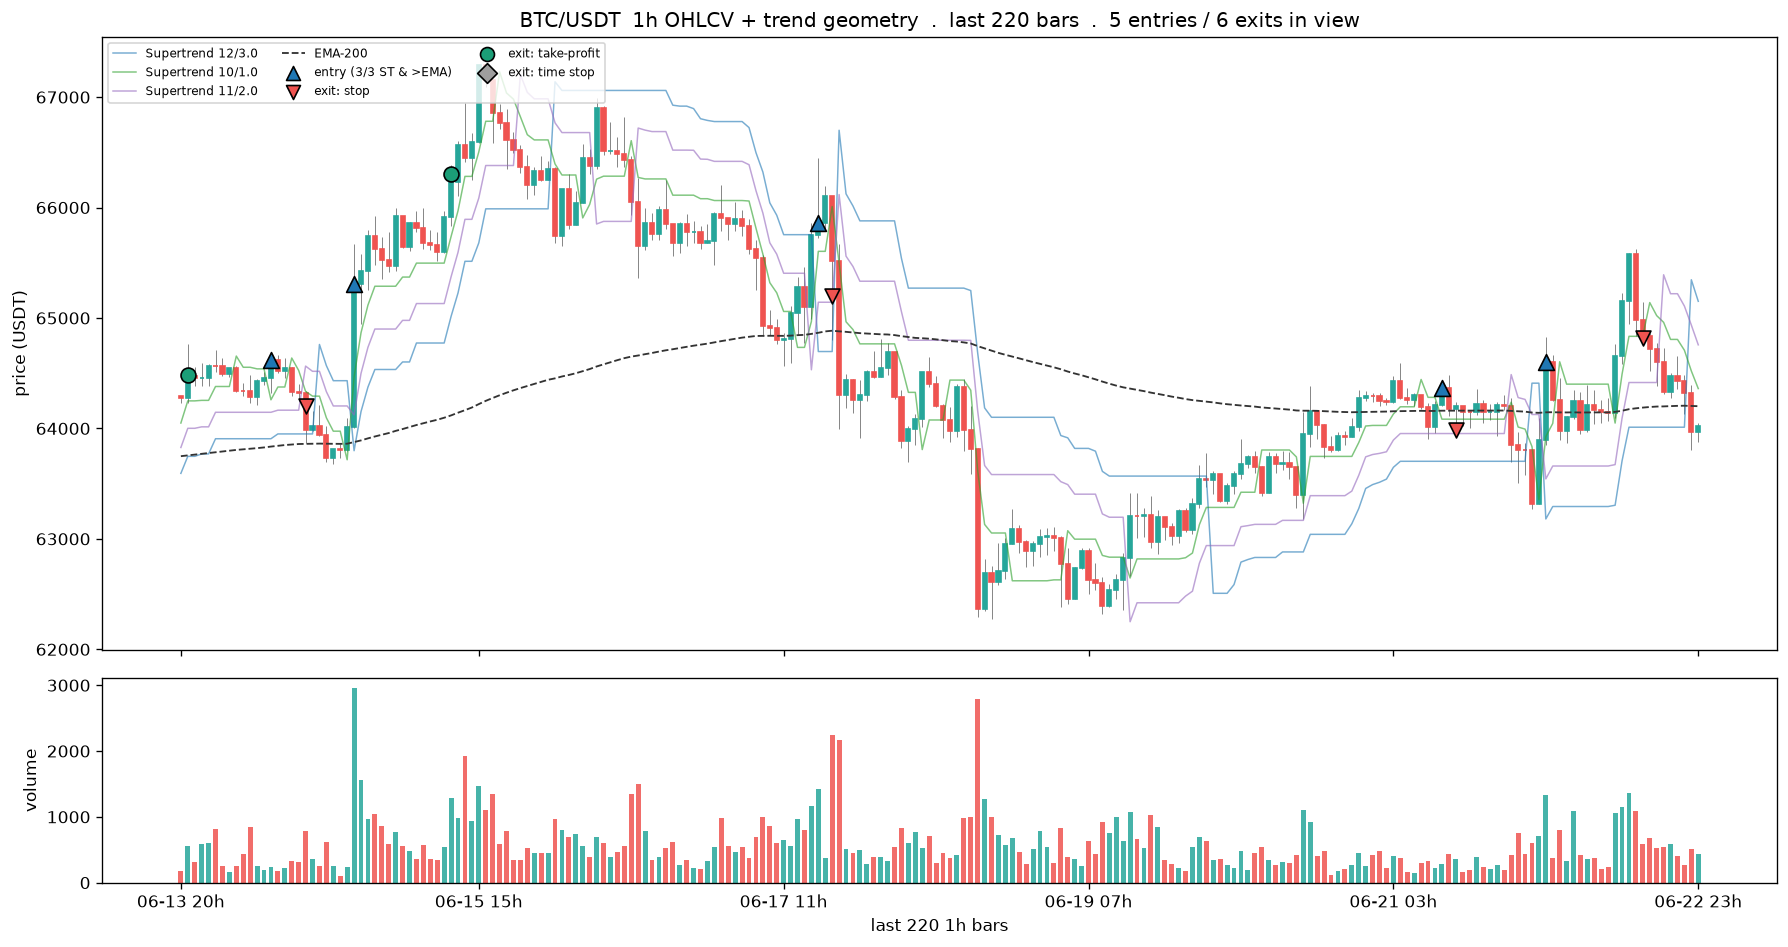

BTC/USDT: 1145 trades total  .  5 entries / 6 exits in the 220-bar window


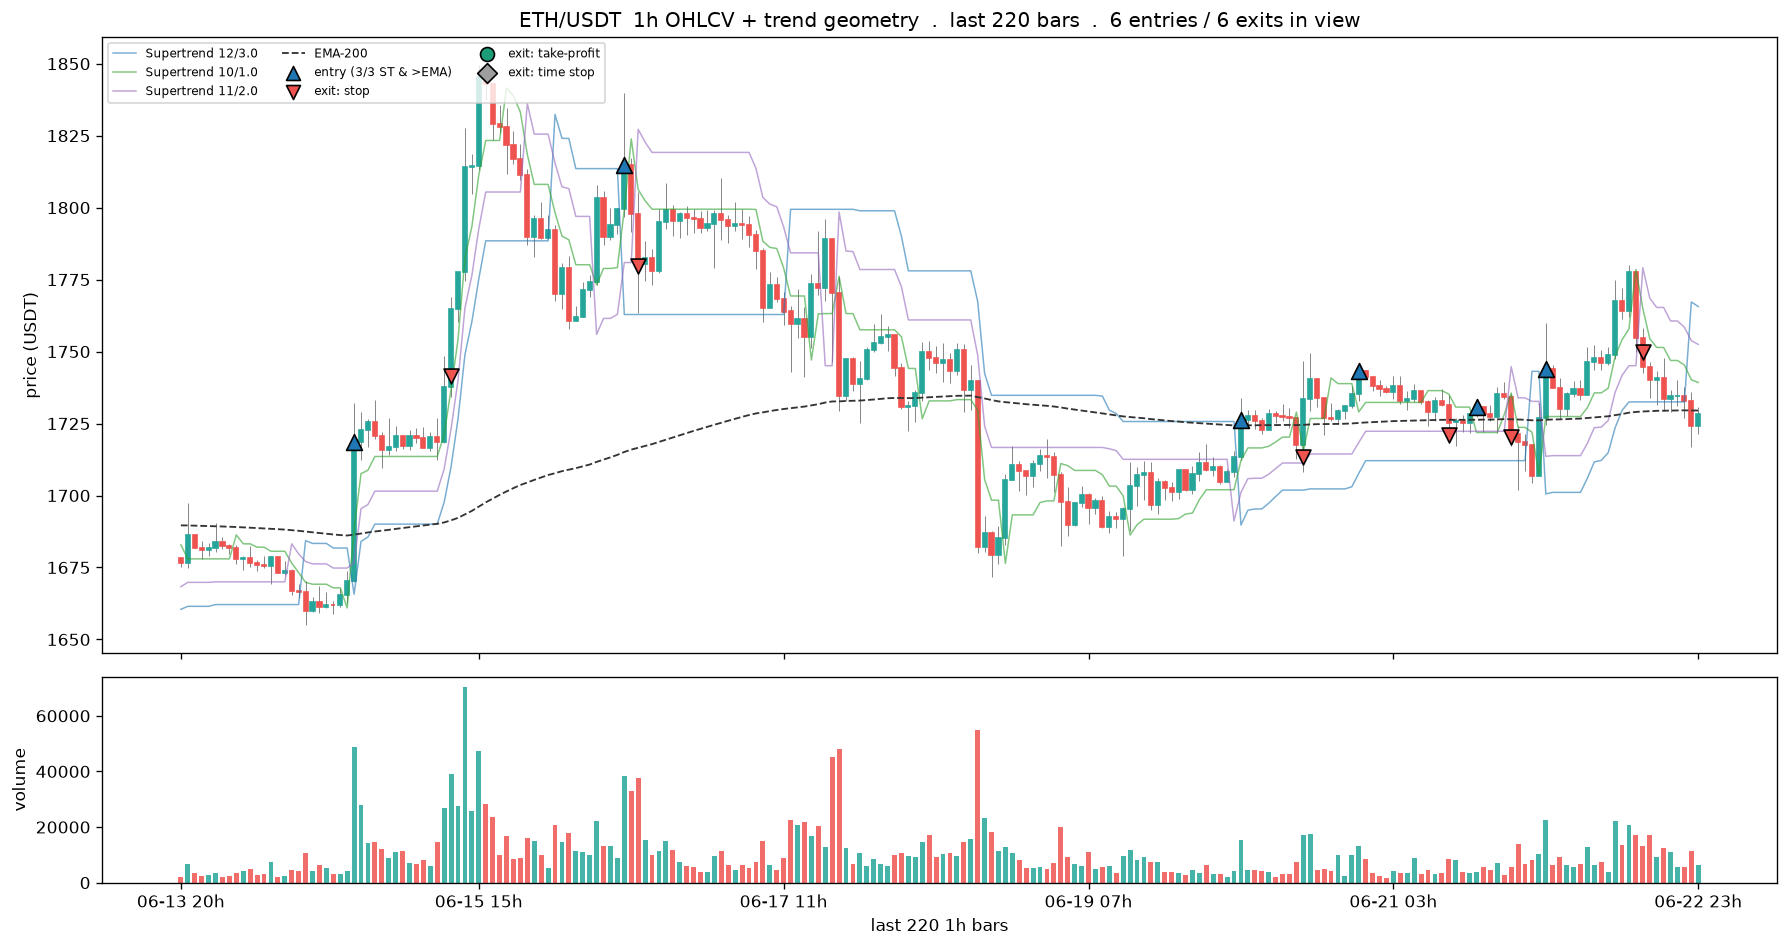

ETH/USDT: 1166 trades total  .  6 entries / 6 exits in the 220-bar window


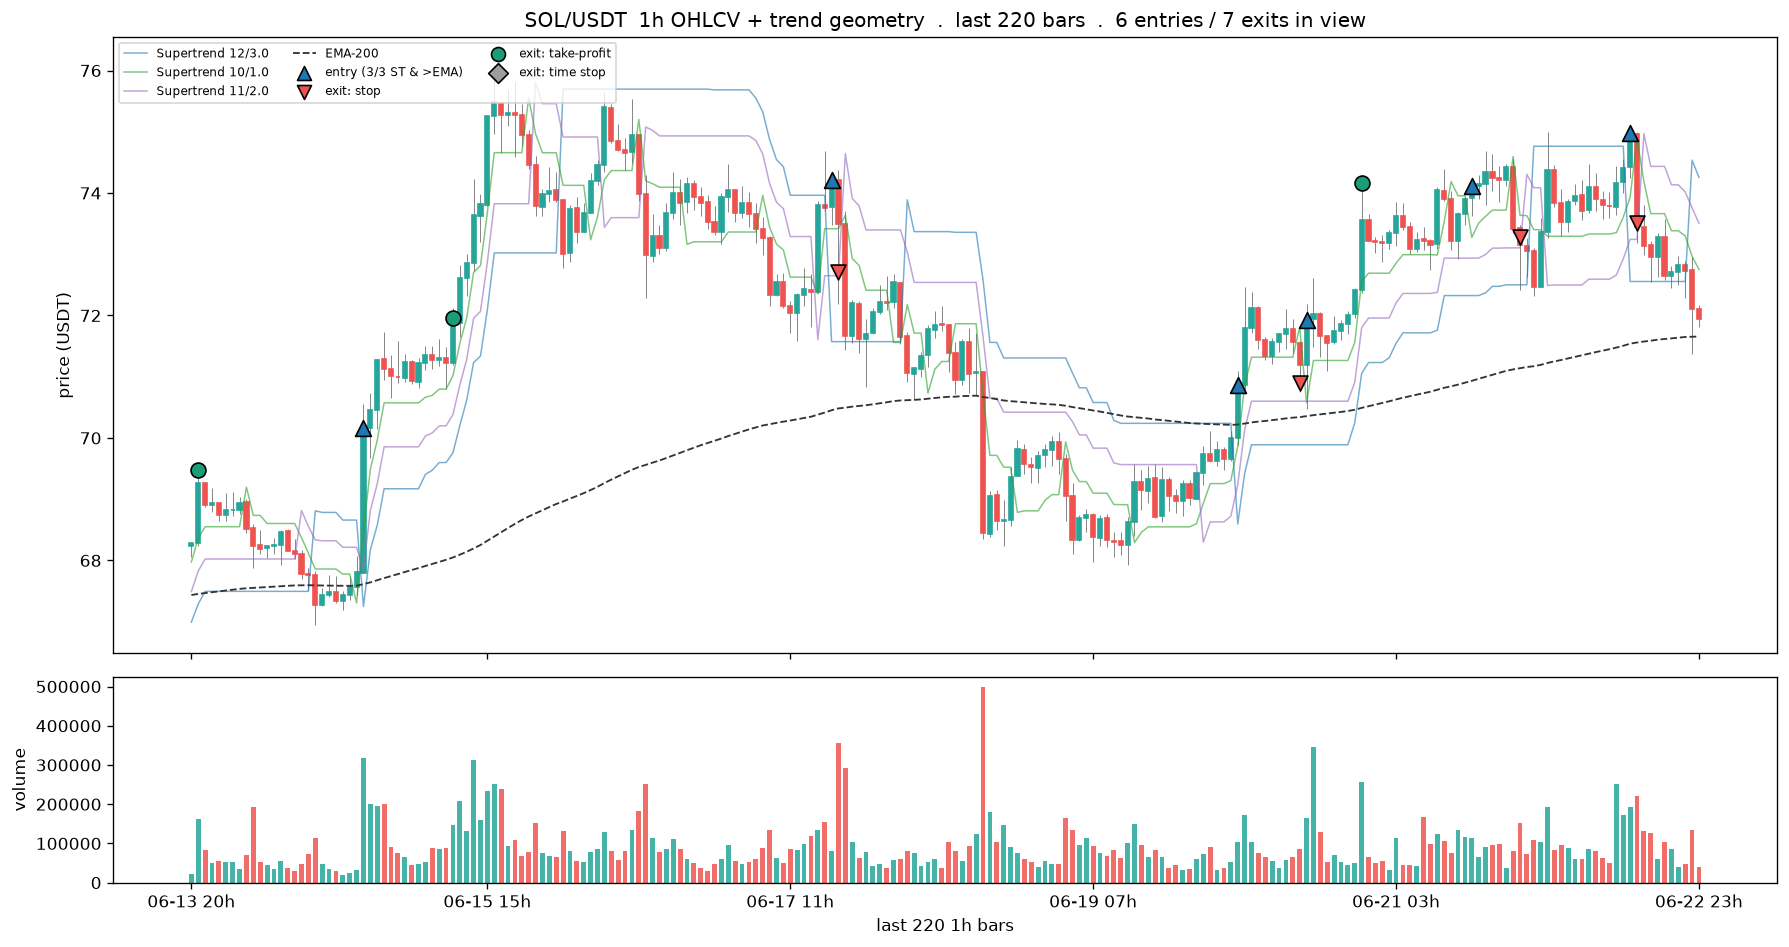

SOL/USDT: 820 trades total  .  6 entries / 7 exits in the 220-bar window


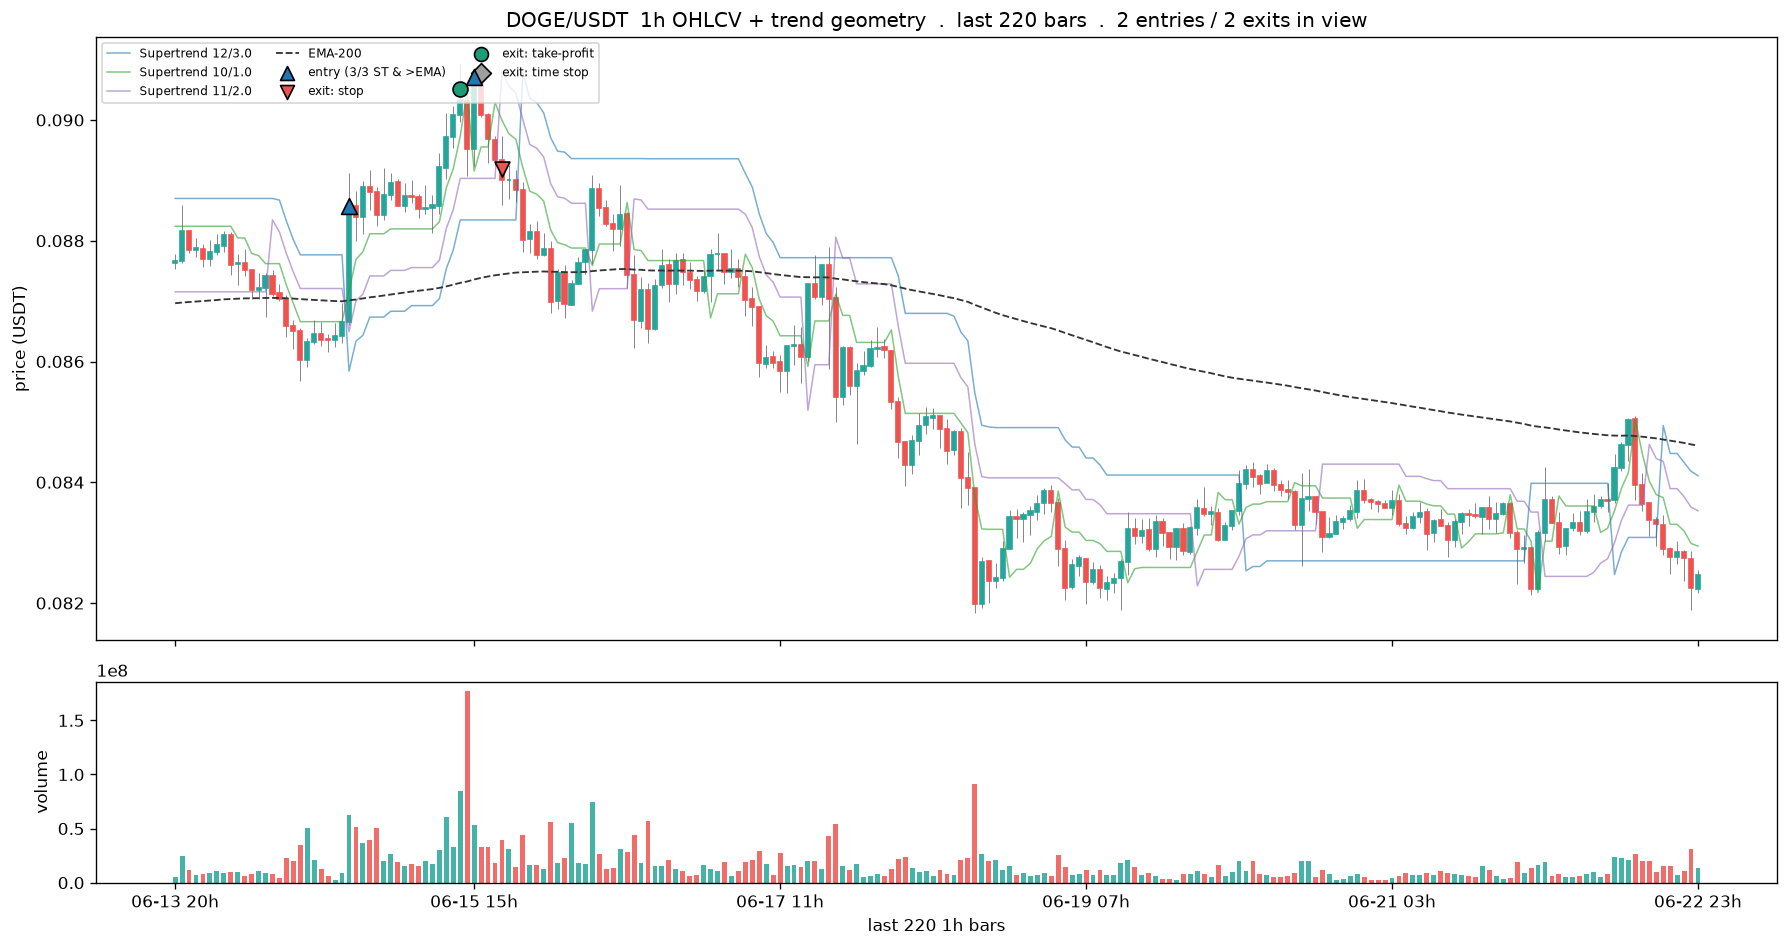

DOGE/USDT: 804 trades total  .  2 entries / 2 exits in the 220-bar window


In [8]:
# --- OHLCV candles + trend geometry across select coins -------------------------------
# A clean overview of WHAT the model trades, before the per-barrier zooms below: real OHLCV
# candlesticks (price + volume) for several coins, each with the trend geometry the entry rule
# reads -- the three Supertrend trailing bands and the EMA-200 filter -- and the entry/exit
# points marked on the bars. Entry triangles fire where all three bands agree on an uptrend and
# price holds above EMA-200; exits are coloured by the barrier that closed the trade. The entry +
# exit mechanics are the SAME functions the exit-geometry sweep runs (exit_geometry_viz), so the
# picture and the scoreboard cannot drift. The candle/volume/trend drawing is kept inline so the
# notebook stands on its own.
import exit_geometry_viz as egv

GALLERY_COINS  = ["BTC/USDT", "ETH/USDT", "SOL/USDT", "DOGE/USDT"]   # any coins with klines on disk
GALLERY_FRAME  = 1            # interval hours (1 = 1h, matches the loaded dataset; 4 = 4h)
GALLERY_WINDOW = 220          # candles to show for legibility; markers are those inside the window
GALLERY_CFG    = dict(stop_mult=2.0, tp_atr=3.0, trail=2.0, tp_decay=False)   # one exit geometry
GALLERY_FEE    = 0.001        # 10 bps per side

_BAND_COL = ["#1f77b4", "#2ca02c", "#9467bd"]                         # the three Supertrend bands
_EXIT_STYLE = {"stop": ("#ef5350", "v", "stop"),                     # marker colour, shape, label
               "tp":   ("#1b9e77", "o", "take-profit"),
               "time": ("#9e9e9e", "D", "time stop")}

def ohlcv_trend_panel(symbol, frame=GALLERY_FRAME, window=GALLERY_WINDOW,
                      cfg=GALLERY_CFG, fee=GALLERY_FEE):
    """Draw one coin: OHLCV candles + Supertrend bands + EMA-200 + entry/exit markers, volume below."""
    bd.configure(frame)                                              # 1h or 4h feature/label geometry
    max_hold = bd.LABEL["horizon_bars"] * 4
    o = bd.load_coin(bd.DEFAULT_KLINES_ROOT, symbol.replace("/", "")).reset_index(drop=True)
    if o.empty:
        print(f"no klines for {symbol} under {bd.DEFAULT_KLINES_ROOT}"); return
    lines, ema, entries, ups = egv.compute_trend(o)                  # 3 Supertrend bands + EMA-200 + entry mask
    trades, _ = egv.simulate_with_path(o, entries, cfg, fee, max_hold)   # which barrier each trade hit

    n = len(o); s = max(0, n - window); e = n - 1; x = np.arange(s, e + 1)
    op, cl = o["open"].to_numpy(), o["close"].to_numpy()
    hi, lo, vol = o["high"].to_numpy(), o["low"].to_numpy(), o["volume"].to_numpy()
    up = cl >= op                                                    # green/red per candle

    fig, (axp, axv) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})
    # OHLC candles: wick = high-low line, body = open-close rectangle
    axp.vlines(x, lo[s:e + 1], hi[s:e + 1], color="#888", lw=0.6, zorder=1)
    for k in range(s, e + 1):
        axp.add_patch(plt.Rectangle((k - 0.3, min(op[k], cl[k])), 0.6, max(abs(cl[k] - op[k]), 1e-9),
                      color="#26a69a" if up[k] else "#ef5350", zorder=2))
    # trend geometry: the bands the entry rule reads
    for li, ln in enumerate(lines):
        axp.plot(x, np.asarray(ln)[s:e + 1], lw=0.9, alpha=0.6, color=_BAND_COL[li],
                 label=f"Supertrend {bd.ST_BANDS[li][0]}/{bd.ST_BANDS[li][1]}")
    axp.plot(x, ema[s:e + 1], color="#333", lw=1.1, ls="--", label=f"EMA-{bd.ST_EMA}")
    # entry / exit points that fall inside the window
    ne = nx = 0
    for t in trades:
        if s <= t["i"] <= e:
            axp.scatter([t["i"]], [t["entry"]], marker="^", s=90, color="#1f77b4",
                        edgecolor="k", zorder=6); ne += 1
        if s <= t["j"] <= e:
            col, mk, _ = _EXIT_STYLE[t["reason"]]
            axp.scatter([t["j"]], [t["exit"]], marker=mk, s=80, color=col,
                        edgecolor="k", zorder=6); nx += 1
    axp.scatter([], [], marker="^", s=70, color="#1f77b4", edgecolor="k", label="entry (3/3 ST & >EMA)")
    for r, (col, mk, lab) in _EXIT_STYLE.items():
        axp.scatter([], [], marker=mk, s=70, color=col, edgecolor="k", label=f"exit: {lab}")
    axp.set_title(f"{symbol}  {bd.INTERVAL} OHLCV + trend geometry  .  last {window} bars  .  "
                  f"{ne} entries / {nx} exits in view")
    axp.set_ylabel("price (USDT)"); axp.legend(loc="upper left", fontsize=7, ncol=3)
    # volume, coloured by candle direction
    axv.bar(x, vol[s:e + 1], width=0.7, alpha=0.85,
            color=np.where(up[s:e + 1], "#26a69a", "#ef5350"))
    axv.set_ylabel("volume")
    ticks = np.linspace(s, e, 6).astype(int)
    axv.set_xticks(ticks)
    axv.set_xticklabels([f"{o['datetime'].iloc[k]:%m-%d %Hh}" for k in ticks])
    axv.set_xlabel(f"last {window} {bd.INTERVAL} bars")
    fig.tight_layout()
    (OUTPUTS / "PNG").mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUTS / "PNG" / f"3-ohlcv-trend-{symbol.replace('/', '')}.png", dpi=150)
    show_fig(fig)
    print(f"{symbol}: {len(trades)} trades total  .  {ne} entries / {nx} exits in the {window}-bar window")

_prev_frame = bd.INTERVAL_HOURS                                      # restore the notebook's frame after
try:
    for _sym in GALLERY_COINS:
        ohlcv_trend_panel(_sym)
finally:
    bd.configure(_prev_frame)                                        # leave bd as the rest of the nb expects

#### Reading the chart

Each panel is one coin over its most recent `GALLERY_WINDOW` bars. Read it in four passes, and the
entry and exit points the model is being trained on become legible.

**The candles and volume.** A candle body spans open to close, green when the bar closed up and red
when it closed down; the thin wick is the high-low range. The bar beneath is that bar's volume,
coloured the same way. Volume that swells into a move is participation confirming it; a move on thin
volume is more easily reversed. This is the raw price the model never sees directly -- every feature
is derived from these bars, and the label is resolved on them.

**The trend geometry.** The three coloured lines are Supertrend trailing bands at three
period/multiplier settings (12/3, 10/1, 11/2). Each sits below price in an uptrend and above price in
a downtrend, flipping side when the trend turns. The dashed line is the EMA-200, the slow filter.
Drawing three bands rather than one is deliberate: a single band flips on noise, so it is their
*agreement* that is the signal. When all three sit below a rising EMA-200 with price above it, the
geometry is aligned long.

**The entries.** A blue up-triangle marks the bar where all three bands agree on an uptrend and price
holds above the EMA-200 -- the exact condition the label is built around. Read the geometry leading
into it: were the bands already stacked in order and pulling apart, a clean trend building, or did
they snap into agreement on one spike, a late entry near a local top? Entries that fire after most of
the move is already on the candles are the ones that tend to give it back.

**The exits.** Every entry resolves into one exit, coloured by the barrier that closed it: a red
down-triangle is the stop, a green circle is the take-profit, a grey diamond is the time stop. The
*mix* is the diagnostic. A frame with edge shows take-profits riding sustained moves out; a frame at
the efficient-market floor shows stops bunched a few bars after entry, the trend reversing back
through the entry almost as often as it continues. On these 1h panels you will see the second picture
far more than the first -- the visual form of the project's headline finding, that 1h direction sits
at the coin-flip line and the +2/-1 ATR barrier bleeds after fees. Set `GALLERY_FRAME = 4` and the
bands lead price more often than they lag it; comparing the two by eye is the fastest way to see why
the decision frame, not the model, is the lever.

**Across coins.** The same geometry behaves differently on BTC than on a faster alt like SOL or DOGE:
wider ATR bands, more whipsaw, larger gaps. Scanning the gallery side by side shows whether an entry
rule is reading a real, broad trend or just fitting one coin's character -- the same question the
cross-sectional work answers with numbers rather than by eye.

### Entry Design on Candles

The trade label is an ATR-scaled triple barrier (`build_dataset_1h.compute_label_return`).
From each candidate entry bar the design draws two levels off the bar's own volatility:

- **high range** = `close x (1 + tgt_atr * ATR%)` -- the upper barrier, the take-profit the entry is aiming at.
- **low range** = `close x (1 - stp_atr * ATR%)` -- the lower barrier, the stop the entry is risking.

The trade resolves the first time price touches either barrier within `horizon_bars`; if neither is
touched it exits at the horizon close. A bar is labelled **1 (win)** when the high range is reached before
the low range, **0** otherwise. The dataset stores features and the label but not OHLC, so the cell below
reloads the raw 1h candles and redraws the barriers exactly as the labeller saw them. Green boxes are wins,
red boxes are losses; the band traces the high/low range across every bar, and ATR% beneath sets their width.

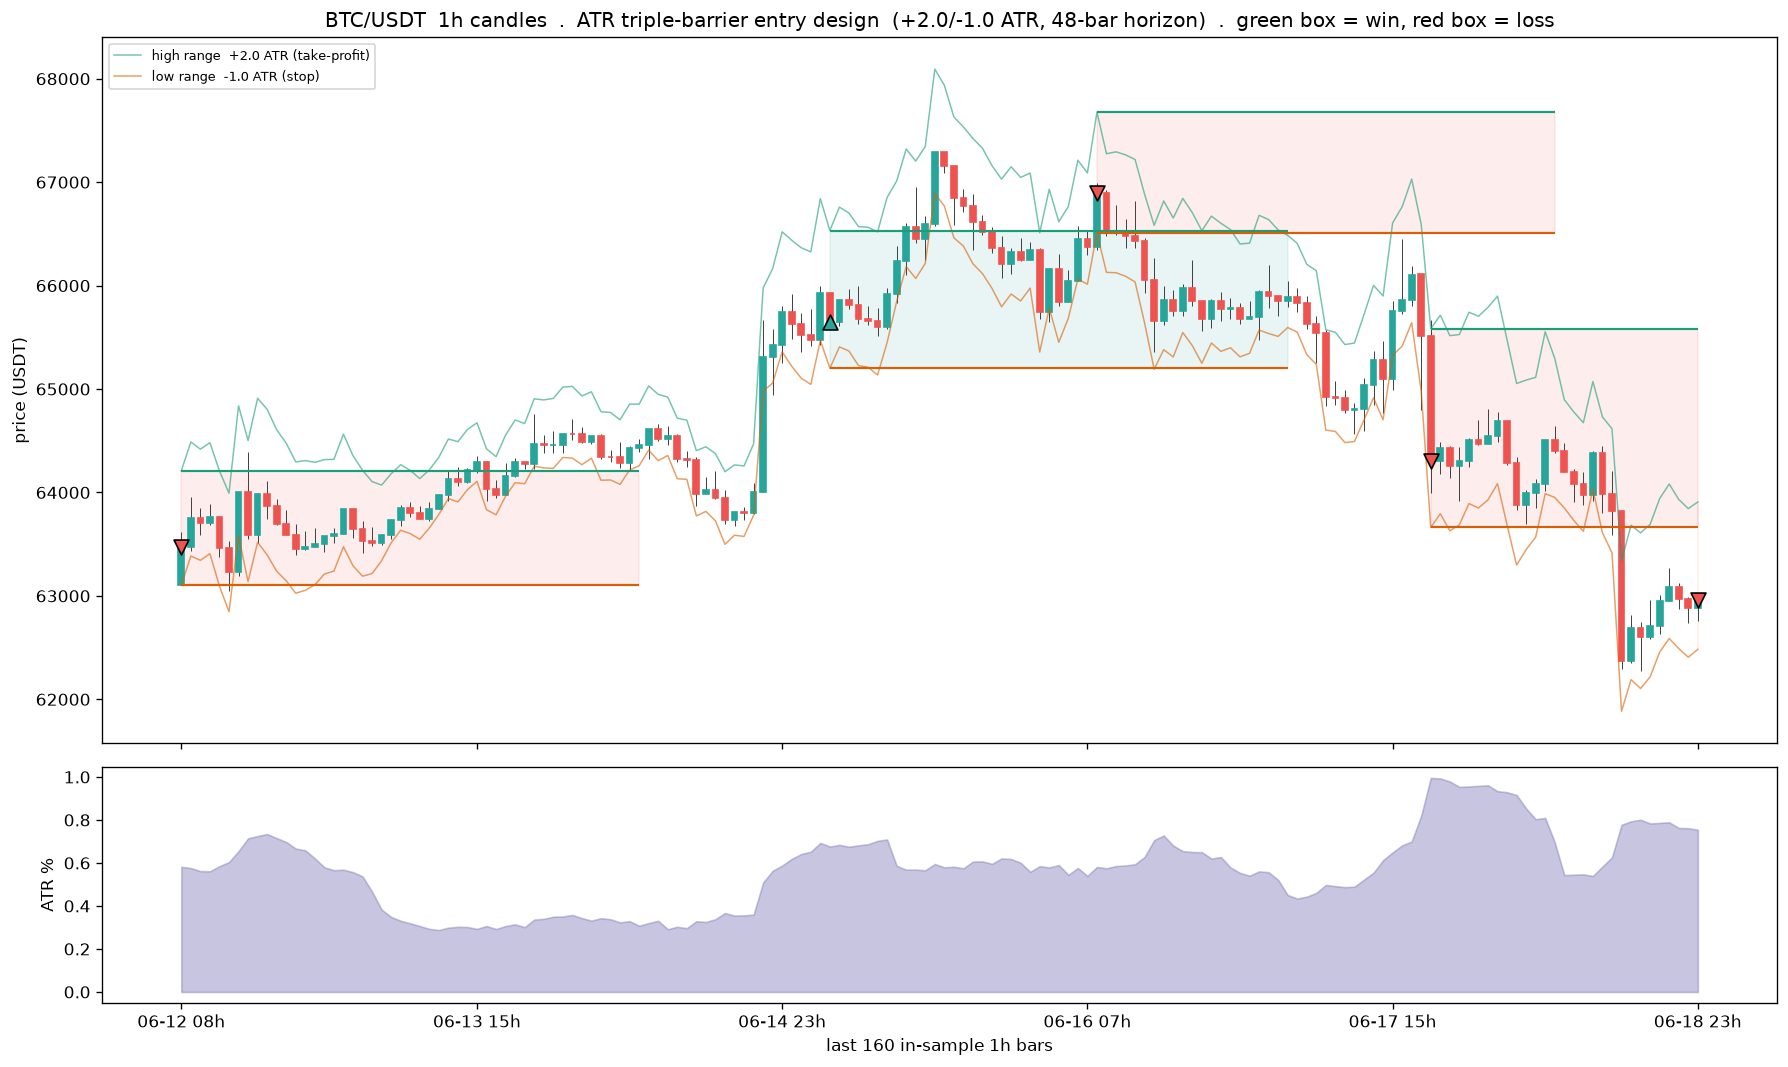

window 2026-06-12 08h -> 2026-06-18 23h  |  111 labelled entries, 35 wins (32%), base rate 31%


In [9]:
# --- Entry design on real candles: the ATR triple-barrier the labeller draws ----------
# Reload raw OHLC (the dataset keeps features+label, not price), recompute the per-bar
# high range (+tgt ATR take-profit) and low range (-stp ATR stop), and overlay the barrier
# box for a handful of entries coloured by outcome. This is the picture of "where we enter".
ENTRY_SYMBOL = "BTC/USDT"     # any coin in df; the kline folder form just drops the slash
WINDOW_BARS  = 160            # number of 1h candles to show
N_ENTRIES    = 5              # entries to annotate with their full barrier box

if df is not None:
    lab = bd.LABEL
    folder = ENTRY_SYMBOL.replace("/", "")
    ohlc = bd.load_coin(bd.DEFAULT_KLINES_ROOT, folder).reset_index(drop=True)
    if ohlc.empty:
        print(f"no raw klines for {folder} under {bd.DEFAULT_KLINES_ROOT}")
    else:
        atr = bd._atr_pct(ohlc, lab["atr_len"]) / 100.0                    # per-bar ATR fraction
        ohlc["hi_range"] = ohlc["close"] * (1 + lab["tgt_atr"] * atr)      # upper barrier (take-profit)
        ohlc["lo_range"] = ohlc["close"] * (1 - lab["stp_atr"] * atr)      # lower barrier (stop)
        labels = df.loc[df["symbol"] == ENTRY_SYMBOL, ["datetime", "label", "trade_ret"]]
        ohlc = ohlc.merge(labels, on="datetime", how="left")               # realised win/loss per bar
        valid = ohlc.dropna(subset=["label"])
        end = int(valid.index.max()); start = max(0, end - WINDOW_BARS + 1)
        win = ohlc.iloc[start:end + 1].reset_index(drop=True)
        x = np.arange(len(win))

        def _candles(ax, w, xs):                                           # OHLC bars without mplfinance
            ax.vlines(xs, w["low"], w["high"], color="#444", linewidth=0.6, zorder=1)
            for i in xs:
                o, c = w["open"].iloc[i], w["close"].iloc[i]
                ax.add_patch(plt.Rectangle((i - 0.3, min(o, c)), 0.6, max(abs(c - o), 1e-9),
                             color=("#26a69a" if c >= o else "#ef5350"), zorder=2))

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 1]})
        _candles(ax1, win, x)
        ax1.plot(x, win["hi_range"], color="#1b9e77", lw=0.9, alpha=0.6,
                 label=f"high range  +{lab['tgt_atr']} ATR (take-profit)")
        ax1.plot(x, win["lo_range"], color="#d95f02", lw=0.9, alpha=0.6,
                 label=f"low range  -{lab['stp_atr']} ATR (stop)")
        ent = win.index[win["label"].notna()].tolist()
        for k in np.linspace(0, len(ent) - 1, min(N_ENTRIES, len(ent))).astype(int):
            t = ent[k]; c = win["close"].iloc[t]
            tgt, stp = win["hi_range"].iloc[t], win["lo_range"].iloc[t]
            won = win["label"].iloc[t] == 1
            wdt = min(lab["horizon_bars"], len(win) - 1 - t)               # box width = horizon, clipped
            col = "#26a69a" if won else "#ef5350"
            ax1.add_patch(plt.Rectangle((t, stp), wdt, tgt - stp, alpha=0.10, color=col, zorder=0))
            ax1.hlines(tgt, t, t + wdt, color="#1b9e77", lw=1.3, zorder=3)
            ax1.hlines(stp, t, t + wdt, color="#d95f02", lw=1.3, zorder=3)
            ax1.scatter([t], [c], marker="^" if won else "v", s=80, color=col, edgecolor="k", zorder=4)
        ax1.set_title(f"{ENTRY_SYMBOL}  1h candles  .  ATR triple-barrier entry design  "
                      f"(+{lab['tgt_atr']}/-{lab['stp_atr']} ATR, {lab['horizon_bars']}-bar horizon)  "
                      f".  green box = win, red box = loss")
        ax1.set_ylabel("price (USDT)"); ax1.legend(loc="upper left", fontsize=8)
        ax2.fill_between(x, 0, atr.iloc[start:end + 1].values * 100, color="#7570b3", alpha=0.4)
        ax2.set_ylabel("ATR %")
        ticks = np.linspace(0, len(win) - 1, 6).astype(int)
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([f"{win['datetime'].iloc[i]:%m-%d %Hh}" for i in ticks])
        ax2.set_xlabel(f"last {len(win)} in-sample 1h bars")
        fig.tight_layout()
        (OUTPUTS / "PNG").mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUTS / "PNG" / "3-entry-design-candles.png", dpi=150)
        show_fig(fig)
        nwin = int(win["label"].eq(1).sum()); ntot = int(win["label"].notna().sum())
        print(f"window {win['datetime'].iloc[0]:%Y-%m-%d %Hh} -> {win['datetime'].iloc[-1]:%Y-%m-%d %Hh}"
              f"  |  {ntot} labelled entries, {nwin} wins ({nwin / max(ntot, 1):.0%}), "
              f"base rate {df.loc[df['symbol'] == ENTRY_SYMBOL, 'label'].mean():.0%}")
else:
    print("build/load the 1h dataset first (see Import Data).")


### Exit Geometry on Candles

Where the entry design draws the barriers a trade is born into, the exit geometry is the path it
travels out along, and the trend it travelled in on. This view mirrors the exact mechanics simulated
in `inputs/exit_geometry_1h.py`. The heavy multi-panel drawing lives in `inputs/exit_geometry_viz.py`
so chapters one and two can show the identical chart; the cell below keeps the pipeline legible:
compute the trend, find the entries, simulate the exits, plot.

**The preceding trend** is three Supertrend trailing bands (`build_dataset_1h._supertrend_band`, the
same lines the live bot trails off) plus the EMA-200 filter. A long entry, the up triangle, fires only
when all three bands agree on an uptrend and price is above EMA-200. The window before each entry is
shaded, and the entry is annotated with its trend snapshot -- Supertrend agreement (0-3), the side of
EMA-200, and RSI -- so the trend data around the entry can be read directly. Beneath the price a panel
tracks the Supertrend agreement building toward 3/3 with EMA-200 slope shaded behind it, and a final
panel carries RSI-14 and the ATR% the barriers are scaled by.

**The exit geometry**, from the entry bar forward:

- an **ATR stop** placed `stop_mult x ATR` below entry;
- a **trailing stop** that ratchets that level up by `trail x ATR` as price rises and never down, the
  orange step line;
- a **take-profit** at `tp_atr x ATR` above entry, optionally **decaying** toward entry over the hold;
- a **time stop** at `max_hold` bars if neither barrier is touched.

The exit marker is coloured by which one closed the trade -- red stop, green take-profit, grey time --
with the realised after-fee return annotated.

[single] BTC/USDT 1h: 1145 trades  exits: 181 TP / 963 stop / 1 time  mean net -0.35%/trade  -> /Volumes/PortableSSD/Github/day-trader/outputs/PNG/3-exit-geometry-candles.png


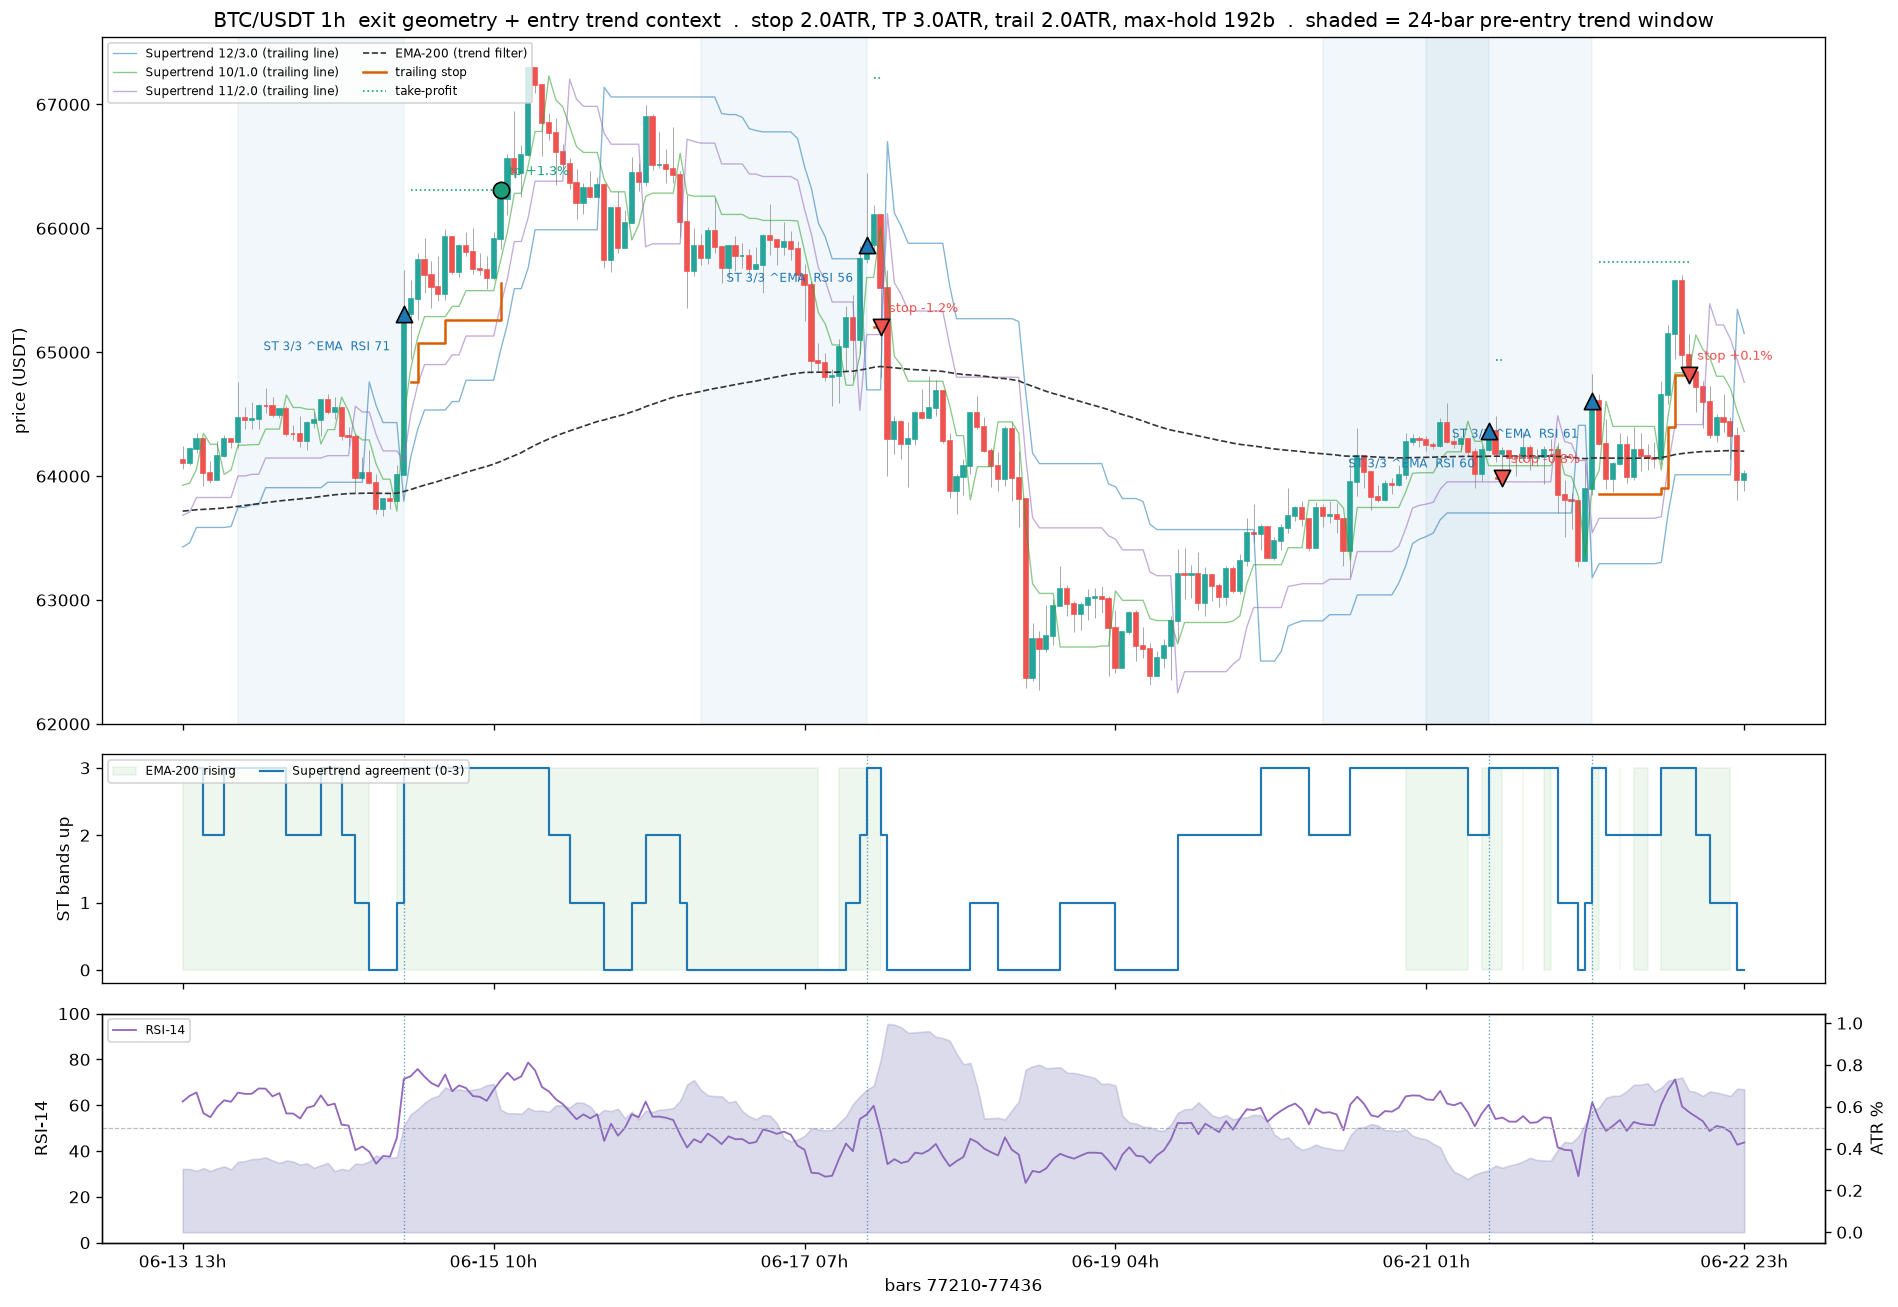

In [10]:
# --- Exit geometry on real candles + the trend data around each entry --------------------
# Heavy multi-panel rendering lives in inputs/exit_geometry_viz.py (single source, also used by
# chapters 1 and 2). Here the pipeline stays legible: trend -> entries -> exit simulation -> plot.
import exit_geometry_viz as egv

EXIT_SYMBOL = "BTC/USDT"                                          # any coin with klines on disk
EXIT_CFG    = dict(stop_mult=2.0, tp_atr=3.0, trail=2.0, tp_decay=False)   # one exit configuration
FEE         = 0.001                                              # 10 bps per side
MAX_HOLD    = bd.LABEL["horizon_bars"] * 4                       # time stop, generous vs the label horizon

ohlc = bd.load_coin(bd.DEFAULT_KLINES_ROOT, EXIT_SYMBOL.replace("/", "")).reset_index(drop=True)
lines, ema, entries, ups = egv.compute_trend(ohlc)               # 3 Supertrend trailing lines + EMA-200 + entries
trades, atrp = egv.simulate_with_path(ohlc, entries, EXIT_CFG, FEE, MAX_HOLD)   # exit mechanics, path recorded
fig = egv.plot_single(ohlc, lines, ema, ups, trades, atrp, EXIT_CFG, MAX_HOLD, FEE,   # shaded pre-entry window,
                      f"{EXIT_SYMBOL} {bd.INTERVAL}",                                  # ST-agreement + RSI panels,
                      OUTPUTS / "PNG" / "3-exit-geometry-candles.png", show=False)     # entry trend annotations
show_fig(fig)                                                     # embed inline (Positron-safe)

### Comparing Exit Geometries

The same entry rarely exits at the same place under different geometries. Holding the entry fixed and
varying only the exit rule isolates what the geometry itself costs or saves. The three panels below
take one shared entry -- labelled with its trend snapshot -- and run it under a fixed TP/stop, a
trailing stop, and a decaying take-profit, drawing where each lands and its after-fee return. This is
the picture the exit-geometry sweep (`inputs/exit_geometry_1h.py`) reduces to a scoreboard: here you
see why one shape beats another on a given trend.

[compare] BTC/USDT 1h: anchored on entry at bar 77414  -> /Volumes/PortableSSD/Github/day-trader/outputs/PNG/3-exit-geometry-compare.png


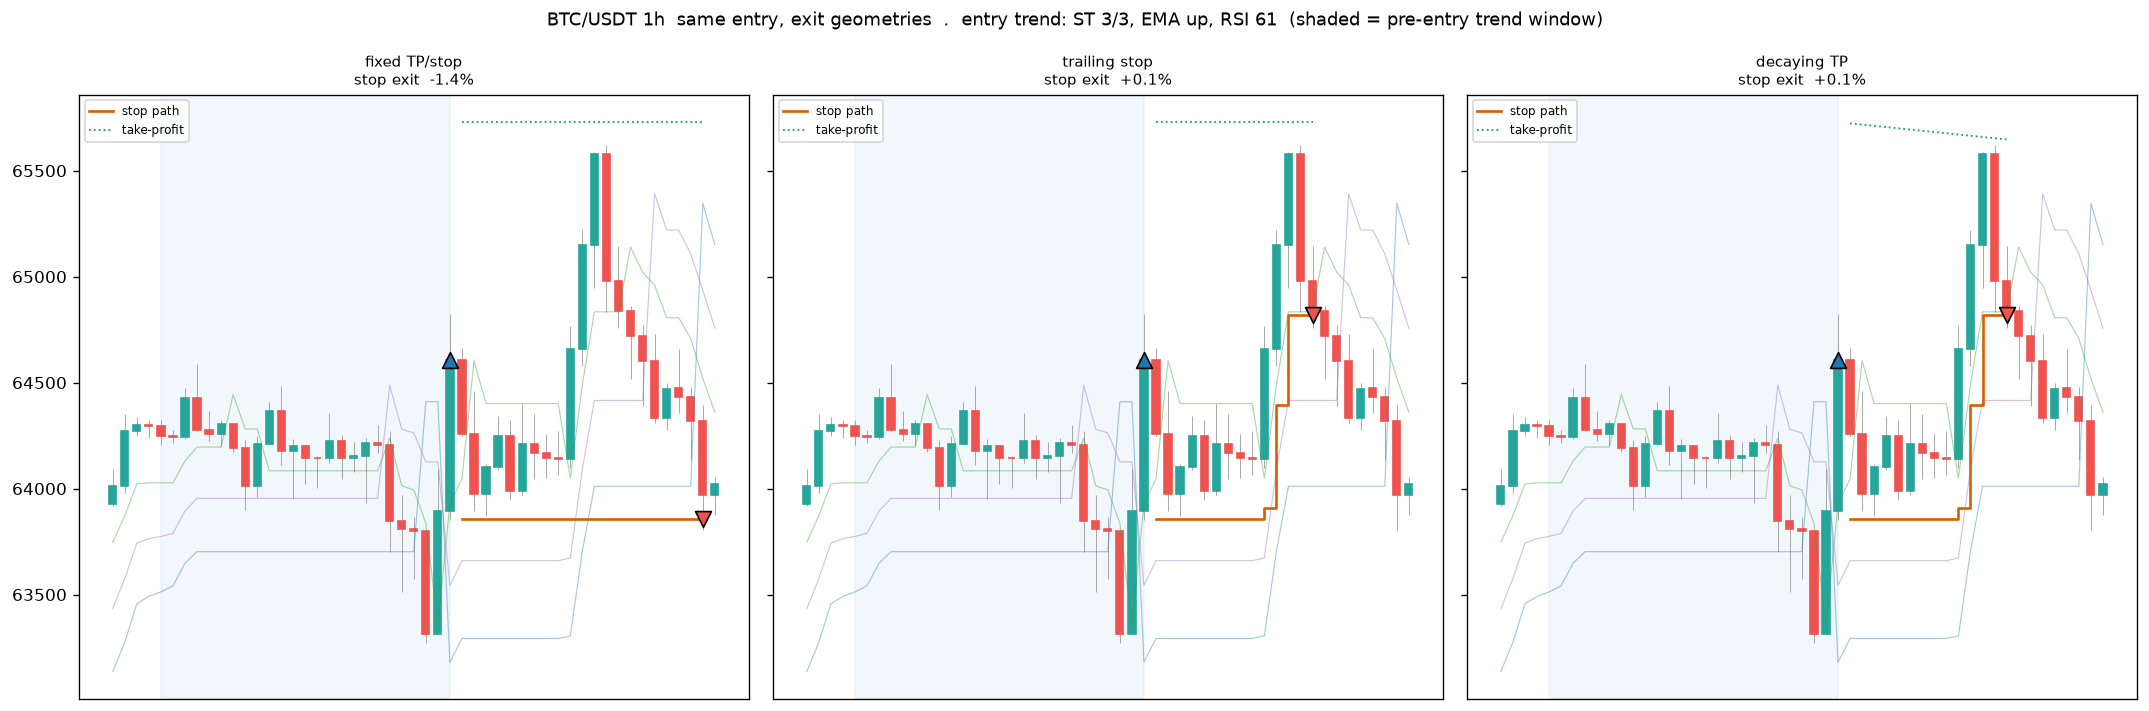

In [11]:
# --- Same entry, several exit geometries: how the shape changes where a trade exits ------
# Reuses ohlc / lines / ema / ups / entries from the Exit Geometry cell above.
COMPARE_CFGS = [("fixed TP/stop", dict(stop_mult=2.0, tp_atr=3.0, trail=0.0, tp_decay=False)),
                ("trailing stop", dict(stop_mult=2.0, tp_atr=3.0, trail=2.0, tp_decay=False)),
                ("decaying TP",   dict(stop_mult=2.0, tp_atr=3.0, trail=2.0, tp_decay=True))]
fig = egv.plot_compare(ohlc, lines, ema, ups, entries, COMPARE_CFGS, MAX_HOLD, FEE,
                       f"{EXIT_SYMBOL} {bd.INTERVAL}",
                       OUTPUTS / "PNG" / "3-exit-geometry-compare.png", show=False)
show_fig(fig)                                                     # embed inline (Positron-safe)

### Sharpening Entries

A +tgt / -stp ATR barrier breaks even (gross of cost) at a win rate of `stp / (stp + tgt)`. For the
default +2 / -1 ATR that is exactly **1/3 = 0.333**, and the unconditional base rate here is ~0.31, so
entering on every bar loses. *Sharpening* means entering only in conditions whose realised win rate clears
that line. The cell below ranks features by how far they separate winners from losers, then plots the win
rate across deciles of each, with the breakeven line drawn. A green decile is a condition that, on its own,
would have produced better-than-breakeven entries; the table reports the best decile per feature and its
lift over breakeven. On the current 1h panel almost nothing clears the line after cost, which is the
documented diagnosis: the lever is a coarser decision frame and cross-sectional ranking, not more 1h features.

In [12]:
# --- Sharpening: which single conditions lift the win rate toward/over breakeven? ------
# Win rate by decile of the most label-separating features, against the barrier breakeven.
# Green decile clears breakeven (a sharper entry); the table ranks the best filters found.
if df is not None and feat:
    lab = bd.LABEL
    breakeven = lab["stp_atr"] / (lab["stp_atr"] + lab["tgt_atr"])         # gross win-rate breakeven
    base = df["label"].mean()
    m1, m0 = df[df.label == 1][feat].mean(), df[df.label == 0][feat].mean()
    sep = ((m1 - m0) / df[feat].std().replace(0, np.nan)).abs().sort_values(ascending=False)
    top = sep.head(8).index.tolist()
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
    rows = []
    for ax, f in zip(axes.ravel(), top):
        d = df[[f, "label"]].dropna()
        q = pd.qcut(d[f], 10, labels=False, duplicates="drop")
        wr = d.groupby(q)["label"].mean()
        ax.bar(wr.index, wr.values, color=np.where(wr.values >= breakeven, "#26a69a", "#ef5350"))
        ax.axhline(breakeven, color="k", ls="--", lw=1)
        ax.axhline(base, color="#888", ls=":", lw=1)
        ax.set_title(f, fontsize=8); ax.set_xticks([])
        rows.append((f, round(float(wr.max()), 3), round(float(wr.max() - breakeven), 3)))
    for a in (axes[0, 0], axes[1, 0]):
        a.set_ylabel("win rate")
    fig.suptitle(f"Win rate by feature decile  .  dashed = breakeven {breakeven:.3f}, "
                 f"dotted = base rate {base:.3f}  .  green decile clears breakeven")
    fig.tight_layout()
    (OUTPUTS / "PNG").mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUTS / "PNG" / "3-entry-sharpening.png", dpi=150)
    plt.show()
    tbl = (pd.DataFrame(rows, columns=["feature", "best_decile_winrate", "lift_over_breakeven"])
           .sort_values("lift_over_breakeven", ascending=False).reset_index(drop=True))
    print("Best single-feature entry filters (in-sample, GROSS of cost):")
    show_table(tbl)
    print(f"cost drag is ~{CONFIG['cost_pct']:.2f}% round trip; on a +{lab['tgt_atr']} ATR target a "
          f"win must clear breakeven by more than that to pay. ")
    if tbl["lift_over_breakeven"].max() <= 0:
        print("NONE clear breakeven gross -> 1h single-feature entries do not sharpen past the barrier math.")
        print("Matches the handover: sharpen via a coarser (4h+) frame and cross-sectional ranking, "
              "not more 1h features.")
else:
    print("build/load the 1h dataset first (see Import Data).")


Best single-feature entry filters (in-sample, GROSS of cost):


,feature,best_decile_winrate,lift_over_breakeven
0,f_ta_pta_vortex_diff,0.342,0.009
1,f_hr_mom_12,0.335,0.001
2,f_ta_dmi_diff,0.333,-0.000
3,f_ta_mfi,0.333,-0.000
4,f_ta_pta_cmo,0.331,-0.003
5,f_hr_rsi,0.331,-0.003
6,f_ta_pta_ppo_hist,0.327,-0.006
7,f_ta_pta_cksp_long_dist,0.323,-0.010


cost drag is ~0.20% round trip; on a +2.0 ATR target a win must clear breakeven by more than that to pay. 


### Survivorship Pipeline

The dataset is only as honest as the panel it is built on. Three dependent stages, run in order, make that panel defensible. Full rationale and the parameter decisions live in `tasks/data-pipeline-methodology.md`.

- **Stage A - acquire dead coins.** A universe built from `exchangeInfo` (live, TRADING only) silently drops every delisted pair and overstates performance. `inputs/acquire_vision.py` enumerates the historical universe from the `data.binance.vision` archive listing instead (612 USDT pairs, ~31% delisted), so the graveyard is included; downloads are checksum-verified and resumable.
- **Stage B - profile the panel.** `inputs/profile_panel.py` measures coverage, gaps, listing/delisting timeline, breadth, survivorship share and liquidity, then derives the split parameters (usable start, minimum history, purge/embargo) from those diagnostics.
- **Stage C - split forward in time.** `inputs/wf_splitter.py` is a forward-chained walk-forward splitter with purge/embargo at every cut and point-in-time per-fold universes - the regime-stability companion to the final-year OOS in `train_model_1h`.

### Stage A

In [13]:
# Stage A: prove the historical universe includes dead coins. Crawl is ~4s, no download here.
# (inputs/ is already on sys.path from the Environment cell.)
import acquire_vision as av

crawl = av.crawl_archive_symbols(quote='USDT', verbose=False)
uni = crawl['symbols']
print(f"historical USDT universe (incl. dead coins): {len(uni)} pairs "
      f"(+{len(crawl['leveraged'])} leveraged excluded)")

# Stage A.5 guard: known-delisted pairs MUST be present, else the list came from a live endpoint.
aud = av.audit_dead_coins(uni)

# Survivorship share vs a dated active snapshot (writes inputs/binance-data/exchange_info_snapshot_<date>.json).
active, snap_path = av.snapshot_exchange_info()
part = av.partition_survivorship(uni, active)
print(f"survivorship: {part['n_universe']} universe / {part['n_active']} active / "
      f"{part['n_delisted']} delisted = {part['delisted_share']:.1%} dead coins")
# The heavy pull (operator's Mac):  python inputs/acquire_vision.py download --interval 1h

historical USDT universe (incl. dead coins): 612 pairs (+52 leveraged excluded)
dead-coin audit: 10/10 known-delisted present in universe
snapshot: 437 active USDT pairs as of 2026-06-24 -> /Volumes/PortableSSD/Github/day-trader/inputs/binance-data/exchange_info_snapshot_2026-06-24.json
survivorship: 612 universe / 424 active / 188 delisted = 30.7% dead coins


### Stage B

In [14]:
# Stage B: panel profiling. Loads the persisted profile; BUILDS it on first run if absent
# (writes run-stamped artefacts under outputs/3A-training-test-data/panel-profile/). Rebuild with:
#     python inputs/profile_panel.py
# Absolute paths come from the module, so this is independent of the notebook's cwd.
import json, os, pandas as pd
import profile_panel as pp

latest = os.path.join(pp.PROFILE_ROOT, 'latest.txt')
if not os.path.exists(latest):
    print('No Stage B profile found -- building over the full klines_1h panel.')
    print('First run only; it streams every coin twice, so expect a few minutes...')
    pp.profile(root=pp.DEFAULT_KLINES_ROOT, out_root=pp.PROFILE_ROOT, make_plot=False)

run = open(latest).read().strip()
md_tbl = pd.read_parquet(os.path.join(run, 'symbol_metadata.parquet'))
dec = json.load(open(os.path.join(run, 'decision_summary.json')))
print('profile run  :', run)
print('symbols      :', len(md_tbl), '| delisted share:', f"{dec['survivorship']['delisted_share']:.1%}")
print('usable start :', dec['usable_start_date'])
print('min history  :', dec['min_history_days'], 'days')
print('purge/embargo:', dec['purge_embargo_days'], 'days', f"({dec['purge_embargo_bars']} bars)")
print('point-of-entry:', dec['point_of_entry_rule'][:90], '...')
display(md_tbl[['symbol', 'first_bar', 'last_bar', 'n_bars', 'coverage', 'max_gap_hours',
                'halt_flag', 'active']].head(10))

profile run  : /Volumes/PortableSSD/Github/day-trader/outputs/3A-training-test-data/panel-profile/2026-06-23T072849Z
symbols      : 384 | delisted share: 0.0%
usable start : 2019-08-01
min history  : 157 days
purge/embargo: 125 days (3000 bars)
point-of-entry: coin enters at its first valid bar (realistic; mirrors when trading would actually begin)  ...


,symbol,first_bar,last_bar,n_bars,coverage,max_gap_hours,halt_flag,active
0,BTCUSDT,2017-08-17 04:00:00+00:00,2026-06-20 23:00:00+00:00,77389,0.9984,75,True,True
1,ETHUSDT,2017-08-17 04:00:00+00:00,2026-06-20 23:00:00+00:00,77389,0.9984,75,True,True
2,BNBUSDT,2017-11-06 03:00:00+00:00,2026-06-20 23:00:00+00:00,75453,0.9984,75,True,True
3,NEOUSDT,2017-11-20 03:00:00+00:00,2026-06-20 23:00:00+00:00,75117,0.9984,75,True,True
4,LTCUSDT,2017-12-13 03:00:00+00:00,2026-06-20 23:00:00+00:00,74565,0.9984,75,True,True
5,QTUMUSDT,2018-03-19 08:00:00+00:00,2026-06-20 23:00:00+00:00,72289,0.9988,10,False,True
6,ADAUSDT,2018-04-17 04:00:00+00:00,2026-06-20 23:00:00+00:00,71597,0.9988,10,False,True
7,TUSDUSDT,2018-05-31 09:00:00+00:00,2026-06-20 23:00:00+00:00,66541,0.9422,3995,True,True
8,IOTAUSDT,2018-05-31 09:00:00+00:00,2026-06-20 23:00:00+00:00,70536,0.9988,10,False,True
9,ONTUSDT,2018-06-08 07:00:00+00:00,2026-06-20 23:00:00+00:00,70356,0.9989,10,False,True


### Stage C

In [15]:
# Stage C: the splitter draws usable_start + per-fold universes from the Stage B run above.
# Reuses `bd` (build_dataset_1h) from the Environment cell.
import wf_splitter as wf
print(wf.METHODOLOGY)
pb, lf, lh = wf.purge_embargo_bars()
print(f'purge/embargo = max(feature lookback {lf}, label horizon {lh}) = {pb} bars '
      f'= {wf.purge_embargo_days()} days')

df_wf = bd.read_frame(bd.DATASET_PATH)
if df_wf is not None:
    if 'in_sample' in df_wf.columns:
        df_wf = df_wf[df_wf['in_sample']].copy()
    sp = wf.WalkForwardSplitter(n_folds=5, test_days=120, scheme='expanding',
                                usable_start=wf.load_usable_start(),
                                universes=wf.load_universes())
    display(sp.fold_table(df_wf))   # per-fold spans + coin counts (C.5 composition audit)
    # Regime-stability metrics (fits a model per fold; run on the .venv):
    # wf.evaluate_walkforward(df_wf, bd.feature_columns(df_wf), sp)
else:
    print('No dataset yet at', bd.DATASET_PATH)

## Splitting methodology: forward-chained, not stratified

Objective: estimate out-of-sample performance under REGIME DRIFT, not interpolation within a
known distribution. The data-generating process drifts across time -- the 2017-18 ICO mania,
the 2021 bull run, the 2022 deleveraging, and the current regime are different processes. A
split that interleaves test bars among training bars borrows the future to predict the past
and yields an error estimate that will not survive live trading.

Stratified sampling is rejected. Stratifying on variance forces similar class proportions
across splits by drawing observations regardless of position in time, which destroys the
temporal ordering that is the whole object of interest. It answers "can the model interpolate
within a known distribution"; the question that matters is "can it extrapolate forward into an
unknown regime." Only a forward-chained split measures that.

Design: expanding/rolling walk-forward on shared calendar boundaries; purge

,fold,train_start,train_end,test_start,test_end,n_train,n_test,n_coins,embargo_days
0,0,2019-08-01,2024-06-23,2024-10-26,2025-02-23,271088,28742,21,125
1,1,2019-08-01,2024-10-21,2025-02-23,2025-06-23,294746,25482,19,125
2,2,2019-08-01,2025-02-18,2025-06-23,2025-10-21,329261,31086,23,125
3,3,2019-08-01,2025-06-18,2025-10-21,2026-02-18,356443,24993,21,125
4,4,2019-08-01,2025-10-16,2026-02-18,2026-06-18,387233,16801,20,125


### Variable Selection

Stage ii: prune the broad candidate set to the subset that earns its place, BEFORE the head-to-head and before any hyperparameter tuning, on the TRAINING window only so the final-year hold-out stays blind (otherwise the blind score is no longer blind).

This is wired to `inputs/variable_selection.py`, a native-Python re-implementation of the R `glmnet` + `coefplot` elastic-net screening idiom, applied to the `f_` feature set and the binary triple-barrier `label` (`family="binomial"`). The R study was the recipe only; no forestry variables are used.

| R (glmnet / coefplot) | Python (`variable_selection.py`) | what it gives |
| --- | --- | --- |
| `cv.glmnet(alpha=1, nfolds=10)` | `enet_cv(l1_ratio=1.0, n_folds=10)` | k-fold CV over a glmnet-style lambda grid; lambda.min / lambda.1se |
| `plot(cv.glmnet)` | `plot_cv_curve()` | binomial deviance vs log-lambda, 1-se whiskers, nonzero counts |
| `coefplot::coefpath` | `plot_coefpath()` / `plot_coefpath_interactive()` | coefficient trajectories (PNG + interactive HTML with a range slider) |
| `coefplot::coefplot(sort="magnitude")` | `plot_coef_ci()` | survivors refit unpenalized (statsmodels Logit) for a 95% CI dot-whisker |
| variables kept at `lambda.1se` | `screen()` | the screened subset, into `SELECTED_FEATURES` |

**Why lasso, why the 1-se rule.** The L1 path drives weak coefficients to exactly zero, so the survivors are a genuine subset, not a re-weighting. `lambda.1se`, the most-regularized lambda within one standard error of the minimum-deviance lambda, is the conventional parsimonious choice: it trades a sliver of fit for a smaller, more stable feature set. Selection runs on TRAIN only. The saga logistic path is slow at the least-regularized end, so the cell samples 25k training rows, which is plenty for the screening picture. Set `feat = SELECTED_FEATURES` and re-run training to fit the head-to-head on the screened subset.

lasso path on 25,000 TRAIN rows x 61 features.
lambda.min=0.000494 (nonzero 46), lambda.1se=0.01121 (nonzero 0)


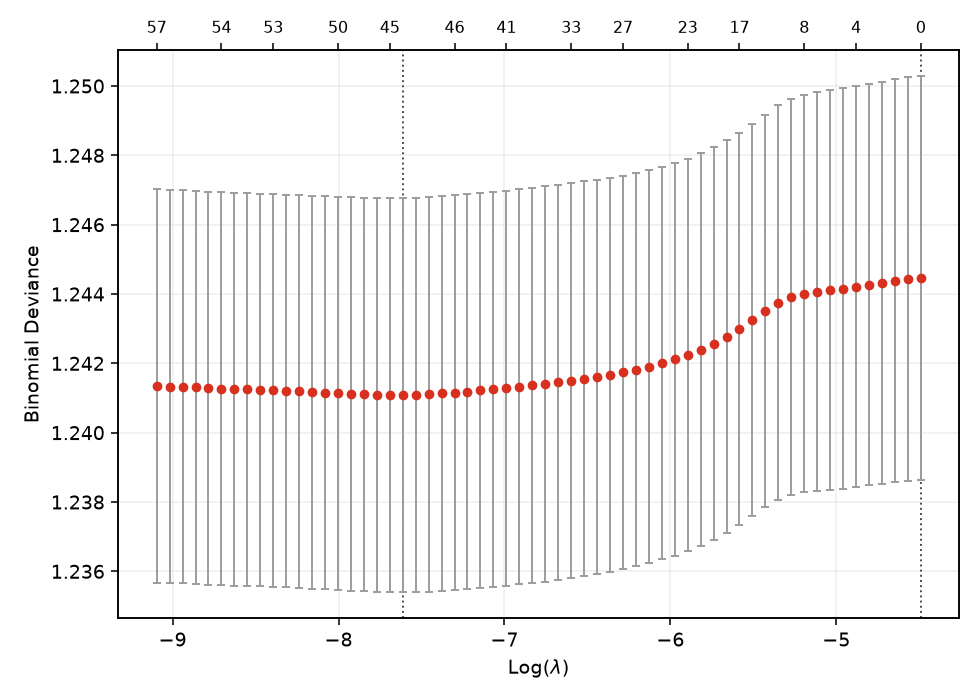

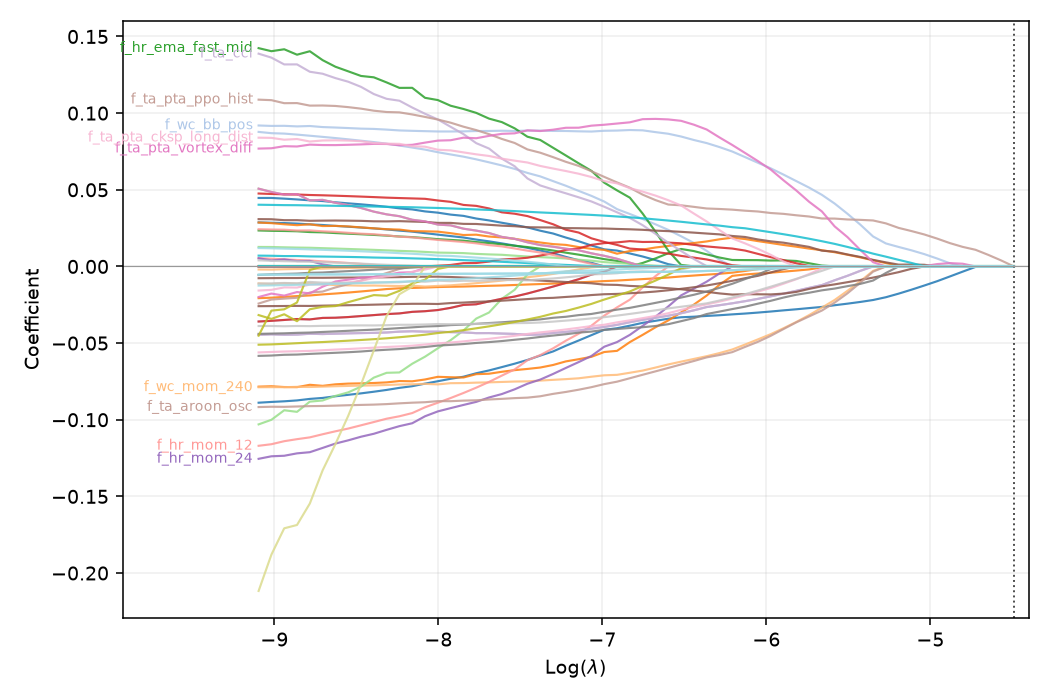

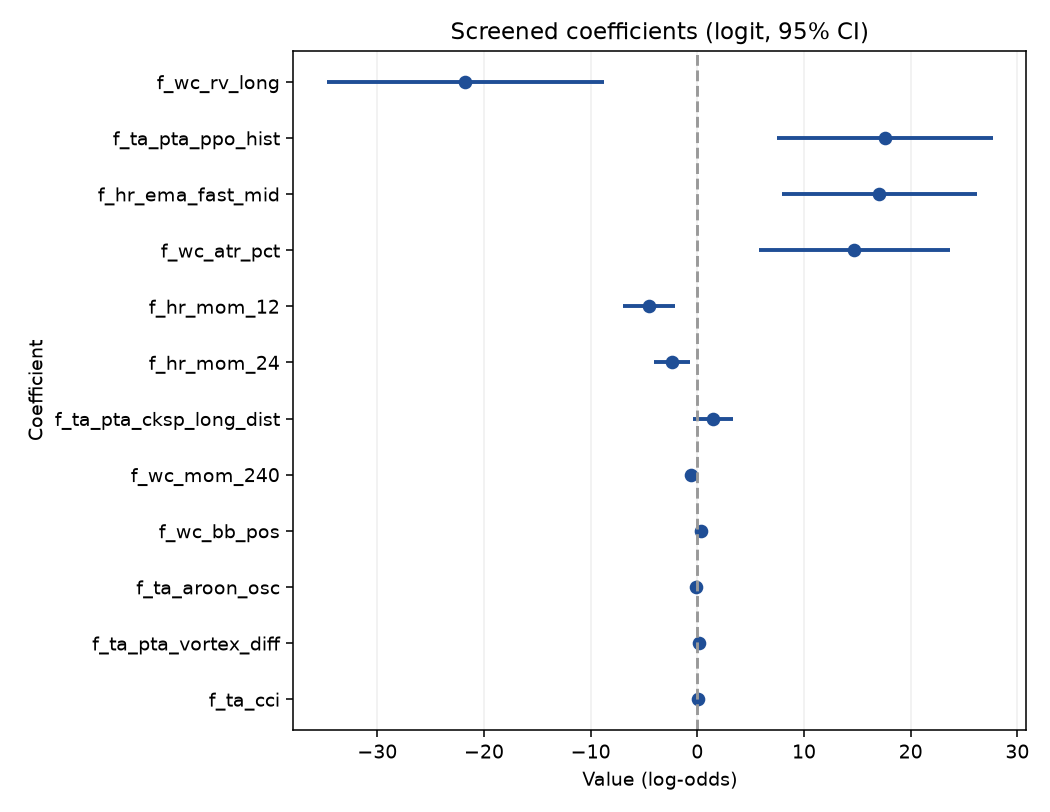


elastic-net kept 46 of 61 features at lambda.1se.
top kept: f_hr_ema_fast_mid(+0.094), f_wc_bb_pos(+0.089), f_ta_pta_vortex_diff(+0.086), f_ta_aroon_osc(-0.086), f_hr_mom_24(-0.083), f_ta_pta_ppo_hist(+0.083), f_wc_mom_240(-0.075), f_hr_mom_12(-0.071), f_ta_pta_cksp_long_dist(+0.070), f_ta_cci(+0.070), f_wc_rv_long(-0.069), f_wc_atr_pct(+0.066), f_wc_ema_fast_mid(-0.066), f_tl_sar_dist(-0.049), f_ta_pta_fisher(-0.046)
interactive coefficient path (open in browser): /Volumes/PortableSSD/Github/day-trader/outputs/AA-evals/varselect/coefpath.html

To train the head-to-head on this subset: set  feat = SELECTED_FEATURES  then re-run training.


In [16]:
# Stage ii: elastic-net (glmnet-analogue) variable selection on the TRAINING split ONLY, via
# inputs/variable_selection.py end-to-end: build_matrix -> enet_cv -> CV curve + coef paths ->
# screen at lambda.1se -> refit survivors for 95% CIs. The blind final year is never touched.
import importlib, variable_selection as vs
importlib.reload(vs)
from IPython.display import Image, display

VARSEL_DIR = OUTPUTS / "AA-evals" / "varselect"
VARSEL_DIR.mkdir(parents=True, exist_ok=True)

if df is not None and feat:
    tr_vs, _te_vs, _cut = t1.split(df)                          # select on TRAIN; OOS stays blind
    samp = tr_vs.dropna(subset=[*feat, "label"])
    if len(samp) > 25000:                                       # saga path is slow; 25k screens fine
        samp = samp.sample(25000, random_state=0)
    X, y, _ = vs.build_matrix(samp, y_col="label", x_cols=feat, standardize=True)
    res = vs.enet_cv(X, y, family="binomial", l1_ratio=1.0, n_folds=10, verbose=False)
    print(f"lasso path on {len(samp):,} TRAIN rows x {len(feat)} features.")
    print(f"lambda.min={res['lambda_min']:.4g} (nonzero {int(res['nonzero'][res['i_min']])}), "
          f"lambda.1se={res['lambda_1se']:.4g} (nonzero {int(res['nonzero'][res['i_1se']])})")

    p_cv  = vs.plot_cv_curve(res, str(VARSEL_DIR / "cv_curve.png"))
    p_cp  = vs.plot_coefpath(res, str(VARSEL_DIR / "coefpath.png"))
    p_cph = vs.plot_coefpath_interactive(res, str(VARSEL_DIR / "coefpath.html"))
    display(Image(filename=p_cv)); display(Image(filename=p_cp))

    kept = vs.screen(res, "1se") or vs.screen(res, "min")        # survivors, largest |coef| first
    SELECTED_FEATURES = [n for n, _ in kept]
    ci_cols = (SELECTED_FEATURES or [n for n, _ in vs.screen(res, "min")])[:12]
    p_ci = vs.plot_coef_ci(samp, "binomial", str(VARSEL_DIR / "coef_ci.png"),
                           y_col="label", x_cols=ci_cols,
                           title="Screened coefficients (logit, 95% CI)")
    display(Image(filename=p_ci))

    print(f"\nelastic-net kept {len(SELECTED_FEATURES)} of {len(feat)} features at lambda.1se.")
    print("top kept:", ", ".join(f"{n}({v:+.3f})" for n, v in kept[:15]))
    print("interactive coefficient path (open in browser):", p_cph)
    print("\nTo train the head-to-head on this subset: set  feat = SELECTED_FEATURES  then re-run training.")
else:
    SELECTED_FEATURES = []
    print("build the 1h dataset first (see Import Data).")

### Training Regime

The split is executed here (in the cell just below), then the models are trained on all history before the final-year cut and scored once on the held-out year; the representativeness and imbalance audit for this split is described in Data Preparation above. Three models compete: logistic regression, random forest, and LightGBM (Tier 1). Each is reported at the 0.5 threshold and under the 60/40 confidence filter (Keller Metric 1); read precision against the base rate, which sits well below 0.5. The full record - Metric 1, Metric 2 (P&L after the 0.20% cost), and Metric 3 (AUC by volatility regime) - is written to `outputs/AA-evals/` by `eval_report.write_comparison`, tagged "head-to-head (1h)", so it sits beside the other runs in `evaluation-scores.md`.

In [17]:
# Split and scoring come from the scripts: t1.split for the 1h final-year hold-out; tm.evaluate,
# tm.build_models, tm.confidence_filtered shared with inputs/train_model.py. Nothing reimplemented.
train, test, cut = t1.split(df)
Xtr, ytr, Xte, yte = train[feat], train["label"], test[feat], test["label"]
base_te = yte.mean()
span = lambda d: f"{d['datetime'].min().date()} to {d['datetime'].max().date()}"
print(f"train {len(train):,} ({span(train)})  .  test {len(test):,} ({span(test)})  .  "
      f"cut {pd.Timestamp(cut).date()}  embargo +/-{t1.EMBARGO_DAYS}d  .  base rate {base_te:.3f}")

train 381,207 (2017-12-15 to 2025-06-16)  .  test 76,789 (2025-06-19 to 2026-06-18)  .  cut 2025-06-18  embargo +/-2d  .  base rate 0.303


In [18]:
# Fast interactive pass. The full-fidelity 3-model run on ALL history is inputs/train_model_1h.py
# (script / auto-eval). The heavy part here is evaluate()'s 5-fold TimeSeriesSplit CV on each model
# (3 models x (5 CV fits + 1 final fit) on ~381k rows = minutes). For the notebook we fit a bounded
# sample taken across the whole period and re-sorted by time, so the time-series CV stays
# chronological. Raise TRAIN_CAP or set it to None for the full run (slow).
TRAIN_CAP = 80_000
if TRAIN_CAP is None or len(train) <= TRAIN_CAP:
    tr_fit = train
else:
    tr_fit = train.sample(TRAIN_CAP, random_state=0).sort_values("datetime")
Xtr_f, ytr_f = tr_fit[feat], tr_fit["label"]
print(f"fitting on {len(tr_fit):,} of {len(train):,} train rows "
      f"({tr_fit['datetime'].min().date()} to {tr_fit['datetime'].max().date()})"
      + ("  [sampled for the notebook; full run is inputs/train_model_1h.py]"
         if (TRAIN_CAP and len(train) > TRAIN_CAP) else ""))

lines, scored = [], []
for name, mdl in tm.build_models(HAVE_LGBM):
    prec, m = tm.evaluate(name, mdl, Xtr_f, ytr_f, Xte, yte, base_te, lines)
    scored.append((prec, name, mdl, m))
print("\n".join(lines))
_, best_name, best_model, best = max(scored, key=lambda t: t[0])
print(f"\nchosen: {best_name}  (precision {best['prec']:.3f} vs base {base_te:.3f}, AUC {best['auc']:.3f})")

fitting on 80,000 of 381,207 train rows (2017-12-16 to 2025-06-16)  [sampled for the notebook; full run is inputs/train_model_1h.py]

--- LogisticRegression ---
  train CV ROC-AUC (5-fold TimeSeriesSplit): 0.528
  test accuracy : 0.484
  test precision(buy): 0.307   (base rate 0.303)
  test recall(buy)   : 0.560
  test ROC-AUC       : 0.504
  confusion matrix [rows=true 0/1, cols=pred 0/1]:
   [[24164, 29352], [10241, 13032]]
  precision lift over base rate: +0.004
  confidence filter (act if p>=0.60 or p<=0.40): keeps 2.7% of test rows (n=2075)
    precision(buy) 0.285  recall 0.663  F1 0.398  (base rate 0.303)

--- RandomForest ---
  train CV ROC-AUC (5-fold TimeSeriesSplit): 0.526
  test accuracy : 0.489
  test precision(buy): 0.310   (base rate 0.303)
  test recall(buy)   : 0.557
  test ROC-AUC       : 0.509
  confusion matrix [rows=true 0/1, cols=pred 0/1]:
   [[24627, 28889], [10319, 12954]]
  precision lift over base rate: +0.007
  confidence filter (act if p>=0.60 or p<=0.40): 

In [19]:
# Honesty gate: precision must clearly beat the base rate and AUC clear 0.55. It does not
# trade; Metric 2 (next cell) is the money test.
margin = best["prec"] - base_te
go = (best["prec"] > base_te + 0.05) and (best["auc"] > 0.55)
verdict = "GO" if go else "NO-GO"
print("HONESTY GATE:", "GO (edge survives out-of-sample)" if go
      else "NO-GO (no demonstrable edge - do not trade)")
MODEL_DIR.mkdir(parents=True, exist_ok=True)   # self-sufficient: works even if the setup cell was not re-run
joblib.dump({"model": best_model, "features": feat, "name": best_name,
             "trained_through": str(pd.Timestamp(cut).date()),
             "test_base_rate": float(base_te), "go": bool(go)}, MODEL_DIR / "model_1h.joblib")
summary = (f"{best_name}: test precision(buy)={best['prec']:.3f} base_rate={base_te:.3f} "
           f"lift={margin:+.3f} AUC={best['auc']:.3f} recall={best['rec']:.3f} acc={best['acc']:.3f} -> {verdict}")
(MODEL_DIR / "model_metrics_1h.txt").write_text(summary + "\n\n" + "\n".join(lines) + "\n")
print("saved", MODEL_DIR / "model_1h.joblib", "and model_metrics_1h.txt")

HONESTY GATE: NO-GO (no demonstrable edge - do not trade)
saved /Volumes/PortableSSD/Github/day-trader/outputs/3B-model-training/model_1h.joblib and model_metrics_1h.txt


In [20]:
# Metrics 2 (P&L after costs) and 3 (regime-stratified AUC) plus AA-evals bookkeeping, from
# inputs/eval_report.py - the same record the script writes. Appends one row to
# outputs/AA-evals/evaluation-scores.md (+ .pdf, .docx), tagged "head-to-head (1h)".
imp = getattr(best_model, "feature_importances_", None)
regime = "f_wc_rv_long" if "f_wc_rv_long" in test.columns else next((c for c in feat if "rv_long" in c), None)
meta = dict(dataset_rows=len(df), n_features=len(feat),
            train_rows=len(train), test_rows=len(test), base_rate=float(base_te),
            cut=str(pd.Timestamp(cut).date()), embargo=t1.EMBARGO_DAYS,
            conf_hi=tm.CONF_HI, conf_lo=tm.CONF_LO, chosen=best_name, verdict=verdict,
            eval_type="head-to-head (1h)",
            dataset_label=f"{len(df):,}r / {len(feat)}f (1h all-market)",
            fi_names=list(feat) if imp is not None else None,
            fi_values=[float(v) for v in imp] if imp is not None else None,
            regime_vol=test[regime].tolist() if regime else None,
            trade_ret=test["trade_ret"].tolist() if "trade_ret" in test.columns else None,
            cost_pct=tm.COST_PCT)
results = [m for (_, _, _, m) in scored]
rec = eval_report.write_comparison(str(OUTPUTS / "AA-evals"), results, yte, meta)
print("evaluation record:", rec["md"])

evaluation record: /Volumes/PortableSSD/Github/day-trader/outputs/AA-evals/2026-06-24/eval-head-to-head-20260624.md


In [21]:
# Teaching display: the strongest tree model's top features. The AA-evals record above
# already saves this chart; this is just an inline look.
tree = next((mdl for (_, name, mdl, _) in scored
             if name in ("LightGBM", "RandomForest")), None)
imp = getattr(tree, "feature_importances_", None) if tree is not None else None
if imp is not None:
    order = np.argsort(imp)[::-1][:15]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh([feat[i] for i in order][::-1], imp[order][::-1], color="#0B3D66")
    ax.set_title(f"{tree.__class__.__name__}: top 15 feature importances")
    fig.tight_layout()
    (OUTPUTS / "PNG").mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUTS / "PNG" / "3B-feature-importance.png", dpi=160)
    plt.show()

### Model Tuning

Two sweeps, both scored on the after-fee out-of-sample scoreboard and logged to the consolidated `outputs/AA-evals/evaluation-scores.md`:

- **Priority 1b - label geometry** (`inputs/sweep_label_1h.py`): the ATR-scaled triple barrier swept over (target, stop, horizon). Each cell reports its own base rate, the breakeven win rate stop/(stop+target), and net P&L/trade after cost, so a lopsided geometry is obvious.
- **Priority 1a - exit geometry** (`inputs/walkforward.py`): stop and take-profit, plus per-coin trailing stops and a time-decaying take-profit - the same question from the exit side.

Settle the two together, then unify the forked label/exit configs. The broad feature set is left broad here on purpose; the variable-selection pass (likelihood-ratio tests, elastic-net paths) prunes predictors before final fitting.

In [ ]:
# The sweeps are full-market and run as scripts from the project .venv:
#   .venv/bin/python inputs/sweep_label_1h.py    # Priority 1b: label geometry (target, stop, horizon)
#   .venv/bin/python inputs/walkforward.py       # Priority 1a: exit geometry (stop, take-profit, trail)
# Both append to the consolidated scoreboard; here we render that one table so tuning reads off it.
#from IPython.display import Markdown, display
#scoreboard = OUTPUTS / "AA-evals" / "evaluation-scores.md"
#if scoreboard.exists():
#    display(Markdown(scoreboard.read_text()))
#else:
#    print("no evaluation-scores.md yet - run a model (cells above) or a sweep script first.")
# Quick inline 1b probe (small grid; the full grid is the script above):
#   import sweep_label_1h as sw
#   coins, scols = sw.precompute(bd.DEFAULT_KLINES_ROOT, bd.DEFAULT_FLOW_CSV, None)
#   sw.score_cell(coins, scols, 3.0, 1.0, 48, tm.COST_PCT/100.0, tm.CONF_HI)

### Model Assessment

A head-to-head scorecard in the style of a caret model-assessment table. For each model it reports the tuned hyperparameters, the in-sample (Full) error, the cross-validated error, and their ratio. Errors are RMSE and MAE on the predicted probabilities - here RMSE is the square root of the Brier score, the caret-style classification RMSE. The RMSEratio (Full RMSE / CV RMSE) flags overfitting: near 1 means the model generalises; well below 1 means it fits the training data far better than it holds up out of sample. Cross-validation is time-ordered (not random folds), and the final year is kept as a single blind test. The table and the best model are logged to the consolidated scoreboard as a "tuning" row.

In [ ]:
# Model Assessment (stage iv), integrated INLINE so it renders in the notebook. Prefers the
# full-fidelity PERSISTED record (the script fits the whole zoo on ALL history); if none exists,
# it runs the assessment here on a bounded sample and renders the caret RMSE table plus the blind
# classification diagnostics directly. Full-fidelity run:
#   .venv/bin/python inputs/model_assessment_1h.py
import glob
import model_assessment_1h as ma
from IPython.display import Markdown, display

recs = sorted(glob.glob(str(OUTPUTS / "AA-evals" / "*" / "model-assessment-*.md")))
if recs:
    print(f"rendering full-fidelity persisted record: {recs[-1]}")
    display(Markdown(open(recs[-1]).read()))
elif df is not None and feat:
    ASSESS_CAP = 60_000                     # bounded for the notebook; the script runs all history
    dfa = (df if len(df) <= ASSESS_CAP
           else df.sample(ASSESS_CAP, random_state=0).sort_values("datetime"))
    print(f"no persisted record - assessing inline on {len(dfa):,} of {len(df):,} rows "
          f"(bounded; full-fidelity is the script).")
    rows, tr_a, te_a, _cut_a = ma.assess(dfa, feat)            # full model zoo, caret RMSE table
    ranked = sorted(rows, key=lambda r: r["cv_rmse"])
    show_table(pd.DataFrame([{"model": r["model"], "hyperparameters": r["hp"],
                              "Full RMSE": round(r["full_rmse"], 4), "CV RMSE": round(r["cv_rmse"], 4),
                              "RMSEratio": round(r["rmse_ratio"], 3)} for r in ranked]))
    best = ranked[0]
    blind = ma.blind_metrics(best["est"], tr_a, te_a, feat, tm.COST_PCT / 100.0, tm.CONF_HI)
    pct = (blind["prec"] / blind["base"] - 1) * 100 if blind["base"] else float("nan")
    verdict = "GO" if (np.isfinite(blind["net"]) and blind["net"] > 0
                       and blind["prec"] > blind["base"] and blind["auc"] > 0.55) else "NO-GO"
    print(f"\nbest by CV RMSE: {best['model']} (RMSEratio {best['rmse_ratio']:.3f})")
    print(f"blind final year: AUC {blind['auc']:.3f}, precision(p>=0.60) {blind['prec']:.3f} "
          f"vs base {blind['base']:.3f} ({pct:+.1f}%), net {blind['net']*100:+.3f}%/trade "
          f"on {blind['trades']:,} trades  ->  {verdict}")
    show_table(pd.DataFrame({"precision": [round(x, 3) for x in blind["precision"]],
                             "recall":    [round(x, 3) for x in blind["recall"]],
                             "F1":        [round(x, 3) for x in blind["f1"]]},
                            index=["0 (no-hit)", "1 (barrier-hit)"]))
    cm = blind["confusion"]
    print(f"Cohen's Kappa {blind['kappa']:.3f}  .  OOB {blind['oob']:.3f}  .  "
          f"confusion [TN {cm[0][0]:,}  FP {cm[0][1]:,}  FN {cm[1][0]:,}  TP {cm[1][1]:,}]")
    print("\nPersist the full-history record:  .venv/bin/python inputs/model_assessment_1h.py")
else:
    print("build the 1h dataset first (see Import Data).")

no persisted record - assessing inline on 60,000 of 458,539 rows (bounded; full-fidelity is the script).
  LogReg.glm       full RMSE 0.4982  CV RMSE 0.5018  ratio 0.993
  LogReg.enet      full RMSE 0.4982  CV RMSE 0.5013  ratio 0.994
  RF               full RMSE 0.4915  CV RMSE 0.4976  ratio 0.988
  LightGBM         full RMSE 0.4277  CV RMSE 0.5001  ratio 0.855
  HistGBM          full RMSE 0.4659  CV RMSE 0.4980  ratio 0.935
  GBM.classic      full RMSE 0.4581  CV RMSE 0.4669  ratio 0.981
  Ensemble.stack   full RMSE 0.4598  CV RMSE 0.4650  ratio 0.989


,model,hyperparameters,Full RMSE,CV RMSE,RMSEratio
0,Ensemble.stack,"stack: lr+rf+gbm, enet meta (l1=0.5 C=0.1)",0.4598,0.4650,0.989
1,GBM.classic,n=150 lr=0.05 depth=3 subsample=0.5,0.4581,0.4669,0.981
2,RF,mtry=auto ntree=400 depth=8,0.4915,0.4976,0.988
3,HistGBM,leaves=31 lr=0.05 iter=600,0.4659,0.4980,0.935
4,LightGBM,leaves=31 lr=0.05 n=600,0.4277,0.5001,0.855
5,LogReg.enet,l1_ratio=0.5 C=0.1,0.4982,0.5013,0.994
6,LogReg.glm,C=1.0,0.4982,0.5018,0.993



best by CV RMSE: Ensemble.stack (RMSEratio 0.989)
blind final year: AUC 0.514, precision(p>=0.60) nan vs base 0.298 (+nan%), net +nan%/trade on 0 trades  ->  NO-GO


,precision,recall,F1
0 (no-hit),0.702,1.0,0.825
1 (barrier-hit),0.000,0.0,0.000


Cohen's Kappa 0.000  .  OOB nan  .  confusion [TN 7,111  FP 0  FN 3,014  TP 0]

Persist the full-history record:  .venv/bin/python inputs/model_assessment_1h.py


### Stability

Confirm any edge is not an artifact: parameter stability, results split by market type, and three baselines - a coin flip, buy-and-hold, and the triple-Supertrend rules benchmark (`inputs/baseline_supertrend_1h.py`, scored after fees through ClaudeTrader's metrics) - plus an optional bootstrap on trade returns. Only then paper trade, then a tiny live allocation. No live trading until a configuration clearly beats all three baselines, out-of-sample and after fees.

In [ ]:
# Monte Carlo robustness (the Stability gate). A single backtest is ONE path; this resamples the
# after-fee per-trade returns 10k times to ask whether the result is robust or luck, and what the
# realistic worst case is. Runnable example: the triple-Supertrend baseline's OOS trades pooled across
# liquid coins; point it at the tuned model's confident-trade returns once the rebuild lands.
# ROBUST requires bootstrap P5 total > 0, p(loss) < 5%, and the sign-flip p-value < 0.05.
import importlib, monte_carlo_1h as mc, exit_geometry_1h as eg
importlib.reload(mc)

if df is not None:
    coins = sorted(s.replace("/", "") for s in df["symbol"].unique())[:20]
    rets = []
    for sym in coins:
        d = bd.load_coin(bd.DEFAULT_KLINES_ROOT, sym)
        if len(d) < 365 * 24 + bd.ST_EMA:
            continue
        oos = d.iloc[-365 * 24:].reset_index(drop=True)
        ent = eg.supertrend_entries(oos)
        rets += [t["ret"] for t in eg.simulate(oos, ent, dict(stop_mult=2.0, tp_atr=3.0, trail=0.0, tp_decay=False))]
    if len(rets) >= 20:
        s = mc.summary(np.array(rets), n_sims=10000)
        show_table(pd.DataFrame(
            {"actual": [f"{s['actual_total']:+.1%}", f"{s['actual_maxdd']:.1%}", f"{s['actual_sharpe']:.2f}"],
             "P5 (worst)": [f"{s['total_p5']:+.1%}", f"{s['maxdd_worst5']:.1%}", f"{s['sharpe_p5']:.2f}"],
             "median": [f"{s['total_p50']:+.1%}", f"{s['maxdd_p50']:.1%}", f"{s['sharpe_p50']:.2f}"],
             "P95": [f"{s['total_p95']:+.1%}", "-", "-"]},
            index=["total return", "max drawdown", "Sharpe"]))
        print(f"trades {s['n_trades']}  prob(loss) {s['prob_loss']:.1%}  "
              f"sign-flip p-value {s['perm_pvalue']:.4f}  ->  {mc.verdict(s)}")
        print("monte carlo record:", mc.write_record(s, str(OUTPUTS / "AA-evals"),
                                                      label="triple-Supertrend baseline (OOS)."))
    else:
        print("not enough trades for Monte Carlo (need >=20).")
else:
    print("build the dataset first (see Import Data).")

,actual,P5 (worst),median,P95
total return,-92.4%,-99.6%,-92.6%,+57.6%
max drawdown,-95.0%,-99.8%,-97.3%,-
Sharpe,-0.43,-2.07,-0.44,-


trades 1926  prob(loss) 91.6%  sign-flip p-value 0.6645  ->  FRAGILE
monte carlo record: /Volumes/PortableSSD/Github/day-trader/outputs/AA-evals/2026-06-24/monte-carlo-20260624.md
